# Reconocimiento de Marcas de Vehículos

In [ ]:
# @title
!pip install gdown -q

import gdown
import zipfile
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import cv2
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.metrics import *
from collections import Counter
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage.feature import hog
from sklearn.model_selection import StratifiedKFold, cross_val_score

Importamos el data set Car Images Dataset (kaggle)

In [ ]:
# @title
file_id = "1fOK0l0ysvjq3F_TQ33DvW3nw7mXw8MJX"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "car_dataset.zip", quiet=False)
with zipfile.ZipFile("car_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/car_dataset")

Downloading...
From (original): https://drive.google.com/uc?id=1fOK0l0ysvjq3F_TQ33DvW3nw7mXw8MJX
From (redirected): https://drive.google.com/uc?id=1fOK0l0ysvjq3F_TQ33DvW3nw7mXw8MJX&confirm=t&uuid=475a123a-014c-4325-9d2e-b0d330c4b56a
To: /content/car_dataset.zip
100%|██████████| 38.0M/38.0M [00:00<00:00, 38.8MB/s]


In [ ]:
# @title
train_dir = "/content/car_dataset/Cars Dataset/train"
test_dir  = "/content/car_dataset/Cars Dataset/test"

clases = os.listdir(train_dir)

Los archivos del dataset estan clasificados en dos carpetas principales, dentro de cada una hay 7 carpetas con imagenes de 7 marcas distintas cada una.

A continuación se presenta el conteo de imagenes disponibles para cada marca:

In [ ]:
# @title
total_imagenes_train = 0
total_imagenes_test = 0
total_imagenes_marca_train = {clase: 0 for clase in clases}
total_imagenes_marca_test = {clase: 0 for clase in clases}

print("Conteo por clase dentro train:")
for clase in clases:
    path_clase = os.path.join(train_dir, clase)
    if os.path.isdir(path_clase):
        n_imagenes_train = len(os.listdir(path_clase))
        total_imagenes_marca_train[clase] = n_imagenes_train
        print(f" - {clase}: {n_imagenes_train} imágenes")
        total_imagenes_train += n_imagenes_train

print(f"TOTAL DE IMÁGENES TRAIN: {total_imagenes_train}")
print()
print("Conteo por clase dentro de test:")
for clase in clases:
    path_clase = os.path.join(test_dir, clase)
    if os.path.isdir(path_clase):
        n_imagenes_test = len(os.listdir(path_clase))
        total_imagenes_marca_test[clase] = n_imagenes_test
        print(f" - {clase}: {n_imagenes_test} imágenes")
        total_imagenes_test += n_imagenes_test
print(f"TOTAL DE IMÁGENES TEST: {total_imagenes_test}")

Conteo por clase dentro train:
 - Hyundai Creta: 271 imágenes
 - Mahindra Scorpio: 316 imágenes
 - Rolls Royce: 311 imágenes
 - Swift: 424 imágenes
 - Toyota Innova: 775 imágenes
 - Tata Safari: 441 imágenes
 - Audi: 814 imágenes
TOTAL DE IMÁGENES TRAIN: 3352

Conteo por clase dentro de test:
 - Hyundai Creta: 67 imágenes
 - Mahindra Scorpio: 75 imágenes
 - Rolls Royce: 74 imágenes
 - Swift: 102 imágenes
 - Toyota Innova: 190 imágenes
 - Tata Safari: 106 imágenes
 - Audi: 199 imágenes
TOTAL DE IMÁGENES TEST: 813


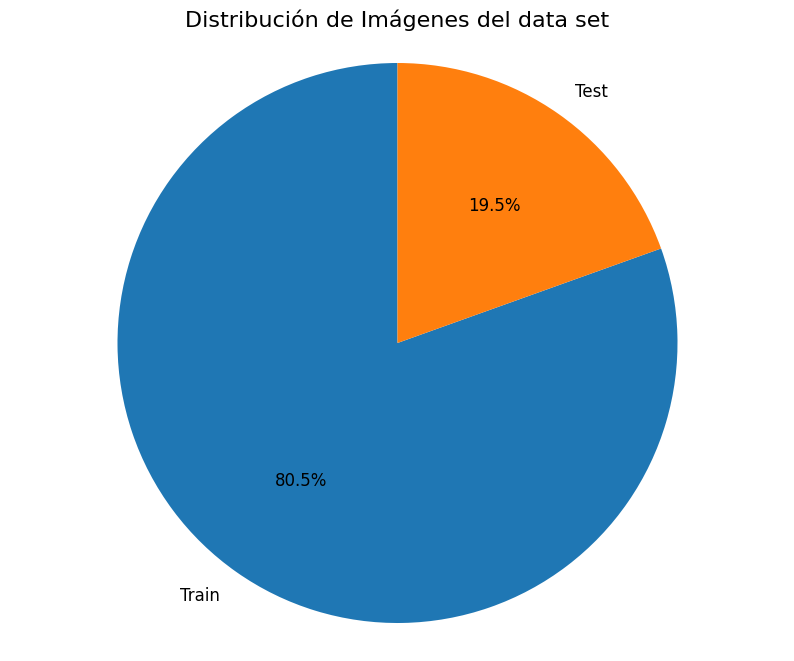

In [ ]:
# @title
labels = ['Train','Test']
sizes = [total_imagenes_train,total_imagenes_test]

plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
plt.axis('equal')
plt.title('Distribución de Imágenes del data set', fontsize=16)
plt.show()

La distribución de imágenes por marca está notablemente desbalanceada. Categorías como Toyota Innova y Audi poseen la mayor cantidad de datos, mientras que otras representan una menor proporción. Para evitar que el modelo desarrolle un sesgo hacia las clases mayoritarias, será necesario aplicar técnicas de oversampling o undersampling.

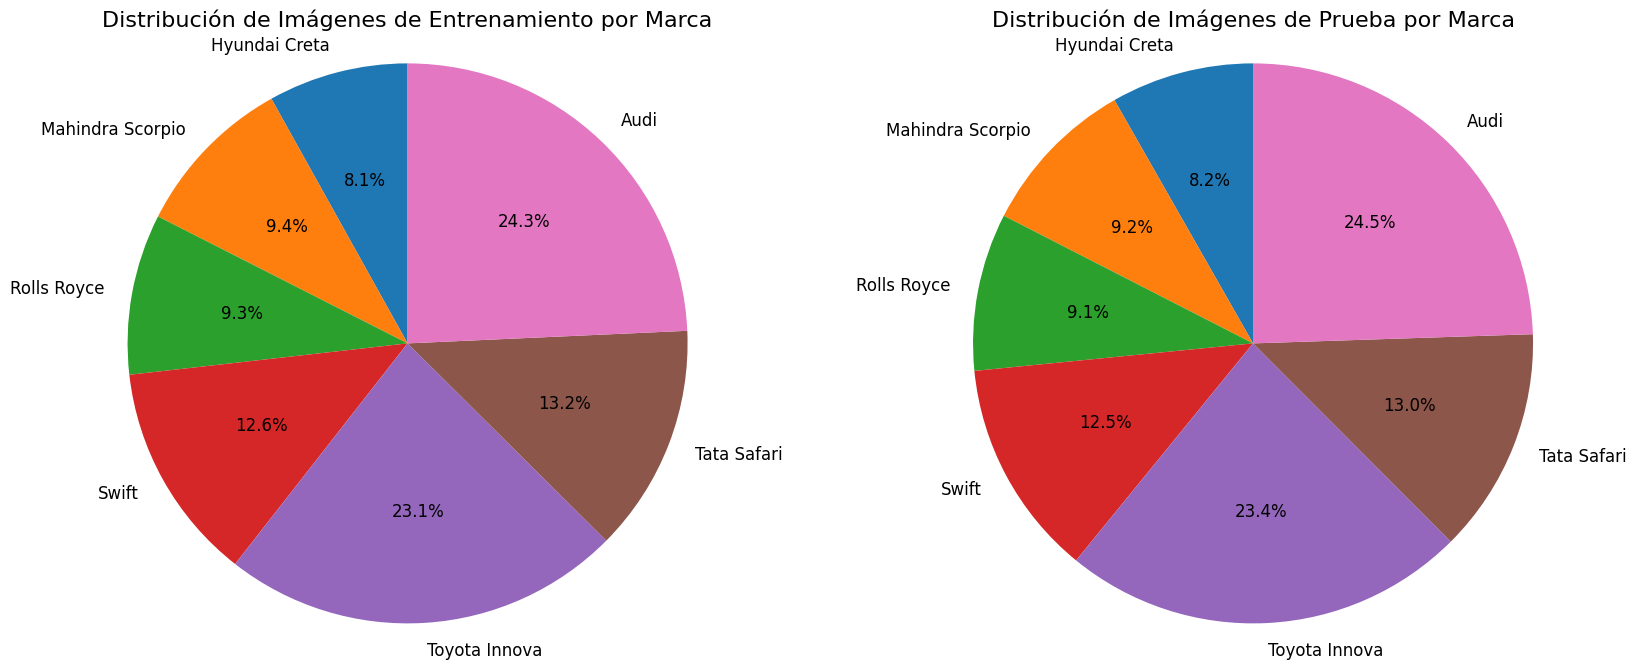

In [ ]:
# @title
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
labels_train = total_imagenes_marca_train.keys()
sizes_train = total_imagenes_marca_train.values()
ax1.pie(sizes_train, labels=labels_train, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
ax1.axis('equal')
ax1.set_title('Distribución de Imágenes de Entrenamiento por Marca', fontsize=16)
labels_test = total_imagenes_marca_test.keys()
sizes_test = total_imagenes_marca_test.values()
ax2.pie(sizes_test, labels=labels_test, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
ax2.axis('equal')
ax2.set_title('Distribución de Imágenes de Prueba por Marca', fontsize=16)
plt.show()

Aunque existen imágenes con dimensiones muy diferentes al resto del dataset, estas representan solo una pequeña fracción del total.

La mayoría de los datos se concentra en un rango razonable, lo que significa que al redimensionarlas no sufrirán deformaciones graves y el modelo podrá procesar las siluetas correctamente durante su entrenamiento

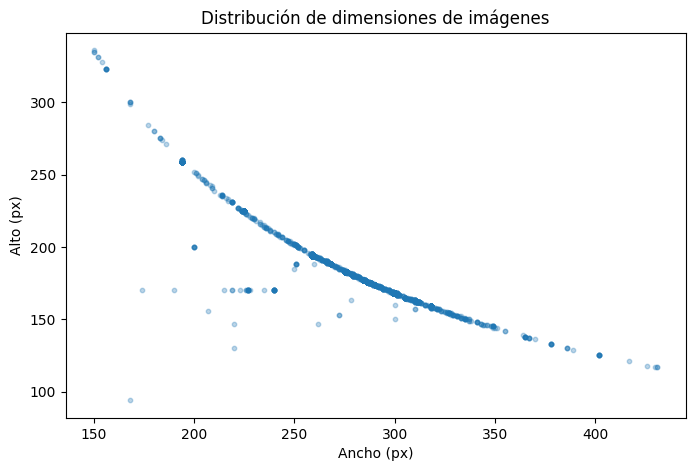

In [ ]:
# @title
anchos, altos, etiquetas = [], [], []
for clase in clases:
    carpeta = os.path.join(train_dir, clase)
    for img_name in os.listdir(carpeta):
        try:
            img = Image.open(os.path.join(carpeta, img_name))
            anchos.append(img.width)
            altos.append(img.height)
            etiquetas.append(clase)
        except:
            pass
plt.figure(figsize=(8,5))
plt.scatter(anchos, altos, alpha=0.3, s=10)
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.title("Distribución de dimensiones de imágenes")
plt.show()

In [ ]:
# @title
stats = {
    "Estadística": ["Media", "Mediana", "Desviación Estándar", "Mínimo", "Máximo"],
    "Ancho (px)": [
        round(np.mean(anchos), 1),
        round(np.median(anchos), 1),
        round(np.std(anchos), 1),
        np.min(anchos),
        np.max(anchos)
    ],
    "Alto (px)": [
        round(np.mean(altos), 1),
        round(np.median(altos), 1),
        round(np.std(altos), 1),
        np.min(altos),
        np.max(altos)
    ]
}

df_stats = pd.DataFrame(stats)
df_stats

,Estadística,Ancho (px),Alto (px)
0,Media,279.5,181.7
1,Mediana,276.0,182.5
2,Desviación Estándar,29.9,22.0
3,Mínimo,150.0,94.0
4,Máximo,431.0,336.0


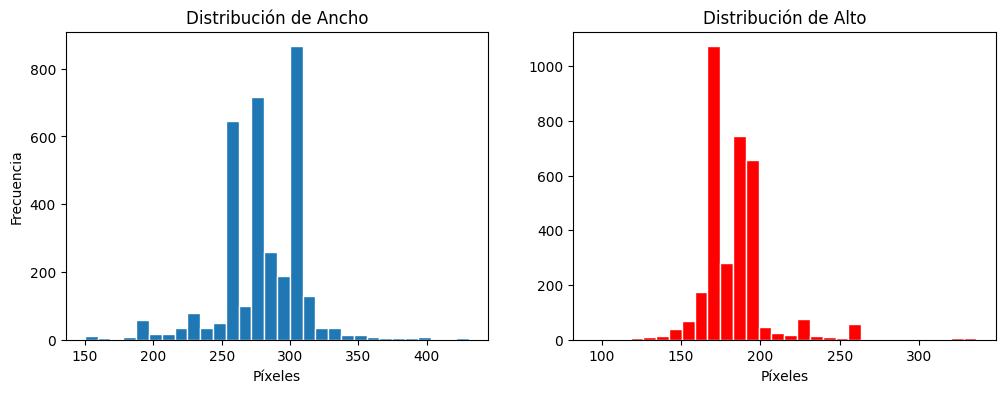

In [ ]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(anchos, bins=30, edgecolor='white')
axes[0].set_title("Distribución de Ancho")
axes[0].set_xlabel("Píxeles")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(altos, bins=30, color = 'red', edgecolor='white')
axes[1].set_title("Distribución de Alto")
axes[1].set_xlabel("Píxeles")

plt.show()

La imagen promedio nos permite observar la composición general del dataset, revelando la orientación más común de los vehículos y los colores predominantes.

En nuestro caso, la mayoría de los autos aparecen de frente. Esto facilita que el modelo encuentre patrones visuales claros y aproveche elementos clave, como la parrilla y el logo de la marca, para lograr una clasificación más precisa.

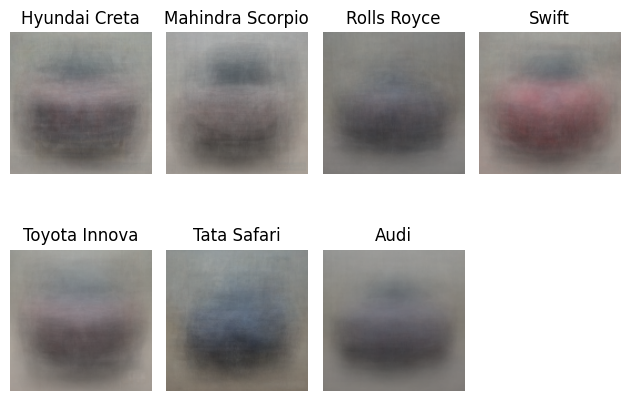

In [ ]:
# @title
def calcular_imagen_promedio(directorio, clase, size=(128, 128)):
    ruta_clase = os.path.join(directorio, clase)
    imagenes = [f for f in os.listdir(ruta_clase) if f.endswith(('.jpg', '.png', '.jpeg'))]

    suma_imagenes = np.zeros((size[0], size[1], 3), np.float32)
    cont = 0

    for img_name in imagenes:
        img_path = os.path.join(ruta_clase, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            suma_imagenes += img
            cont += 1

    img_promedio = suma_imagenes / cont
    return img_promedio.astype(np.uint8)

for i in range(7):
  clase_ejemplo = clases[i]
  img_avg = calcular_imagen_promedio(train_dir, clase_ejemplo)
  ax= plt.subplot(2, 4,1+i)
  ax.imshow(img_avg)
  plt.axis('off')
  ax.set_title(clase_ejemplo)
plt.tight_layout()
plt.show()

La luminosidad en una imagen es una variable clave. Valores demasiado altos o muy bajos pueden ocultar características importantes de los autos. Por ello, lo ideal es que se mantenga en un punto medio.

En este caso, la luminosidad promedio de cada marca se encuentra dentro de un rango aceptable para el entrenamiento del modelo.

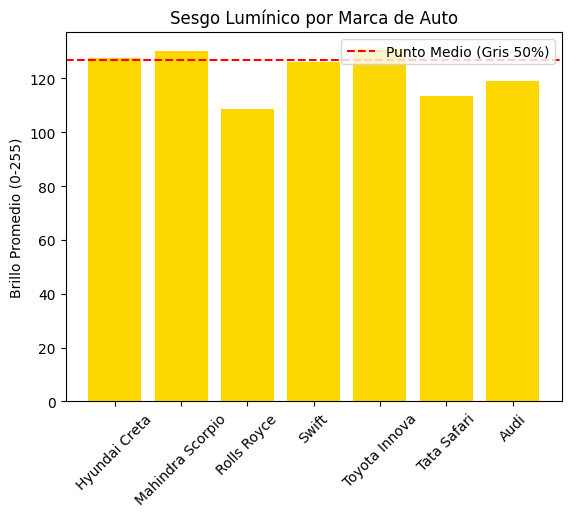

In [ ]:
# @title
def analizar_brillo(directorio, clases):
    medias_brillo = []

    for clase in clases:
        ruta_clase = os.path.join(directorio, clase)
        imagenes = os.listdir(ruta_clase)
        brillos_clase = []

        for img_name in imagenes[:200]:
            img = cv2.imread(os.path.join(ruta_clase, img_name))
            if img is not None:
                gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                brillos_clase.append(np.mean(gris))

        medias_brillo.append(np.mean(brillos_clase))

    plt.bar(clases, medias_brillo, color='gold')
    plt.axhline(y=127, color='r', linestyle='--', label='Punto Medio (Gris 50%)')
    plt.ylabel("Brillo Promedio (0-255)")
    plt.title("Sesgo Lumínico por Marca de Auto")
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

analizar_brillo(train_dir, clases)

#Preproccesamiento

###Funciones para resaltar caracteristicas y extraccion de siluetas

###El HOG es un descriptor de características que se utiliza para identificar objetos basándose en su forma y estructura. En lugar de mirar píxel por píxel, analiza cómo cambia la intensidad de la luz (gradientes) y en qué dirección ocurren esos cambios.

###Con el objetivo de entrenar al modelo solamente con las caracteristicas mas relevantes de cada imagen al final se retorna un vector con los datos mas destacados de HOG y HSV, cone ste arreglo de datos se entrenara a los modelos.


In [ ]:
# @title
def preprocesar_imagen(img_bgr, size=(128, 128)):
    img = cv2.resize(img_bgr, size)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)) #resalta los bordes en zonas de bajo contraste antes de calcular los gradientes.
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    img_eq = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    return img_eq

def extraer_caracteristicas(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hog_feats = hog(
        gray,
        orientations=9, #divide el círculo de direcciones (0-180°) en 9 "recipientes" (bins).
        #Es el número ideal para capturar la estructura humana o de objetos comunes sin sobrecargar el vector de datos.
        pixels_per_cell=(8, 8), #captura estructuras más generales, lo que también reduce el tamaño final del vector.
        cells_per_block=(2, 2), #normaliza la iluminación comparando grupos de 4 celdas (2x2). Esto ayuda a que el descriptor sea invariante a cambios de luz
        block_norm='L2-Hys', #evita que los gradientes muy fuertes (como un brillo puntual) dominen sobre el resto de la forma.
        feature_vector=True
    )
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    h_hist = cv2.calcHist([hsv], [0], None, [16], [0, 180]).flatten() #Detecta el "color" puro (ej. es rojo o es azul).
    s_hist = cv2.calcHist([hsv], [1], None, [16], [0, 256]).flatten() #Detecta la "pureza" del color.
    color_feats = np.concatenate([h_hist, s_hist])
    color_feats /= (color_feats.sum() + 1e-7)  # normaliza

    return np.concatenate([hog_feats, color_feats])

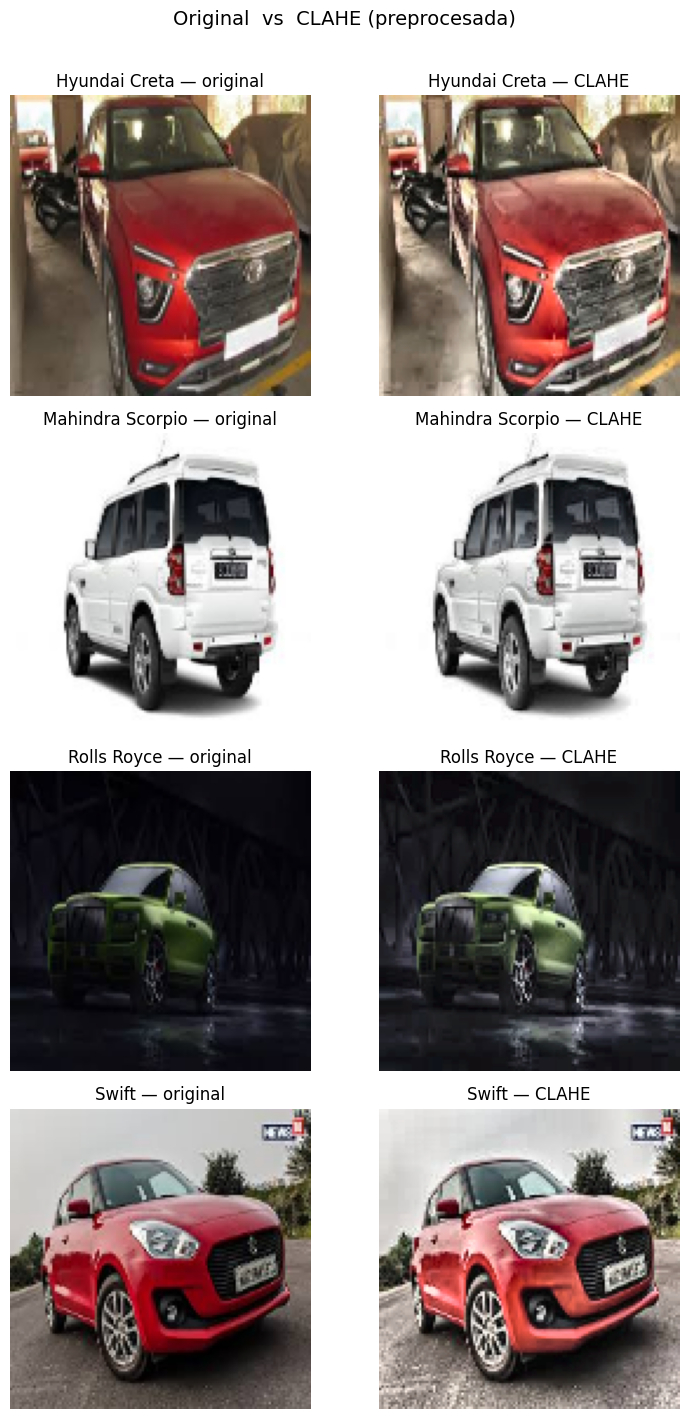

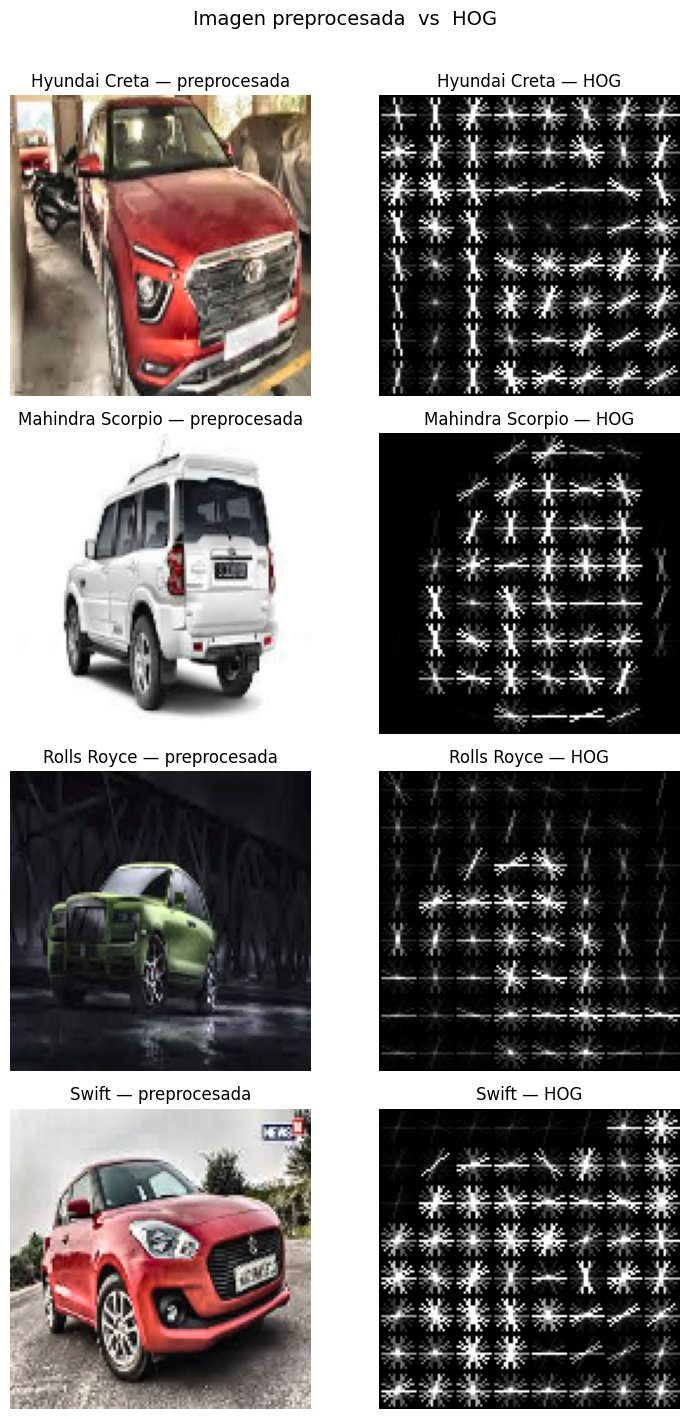

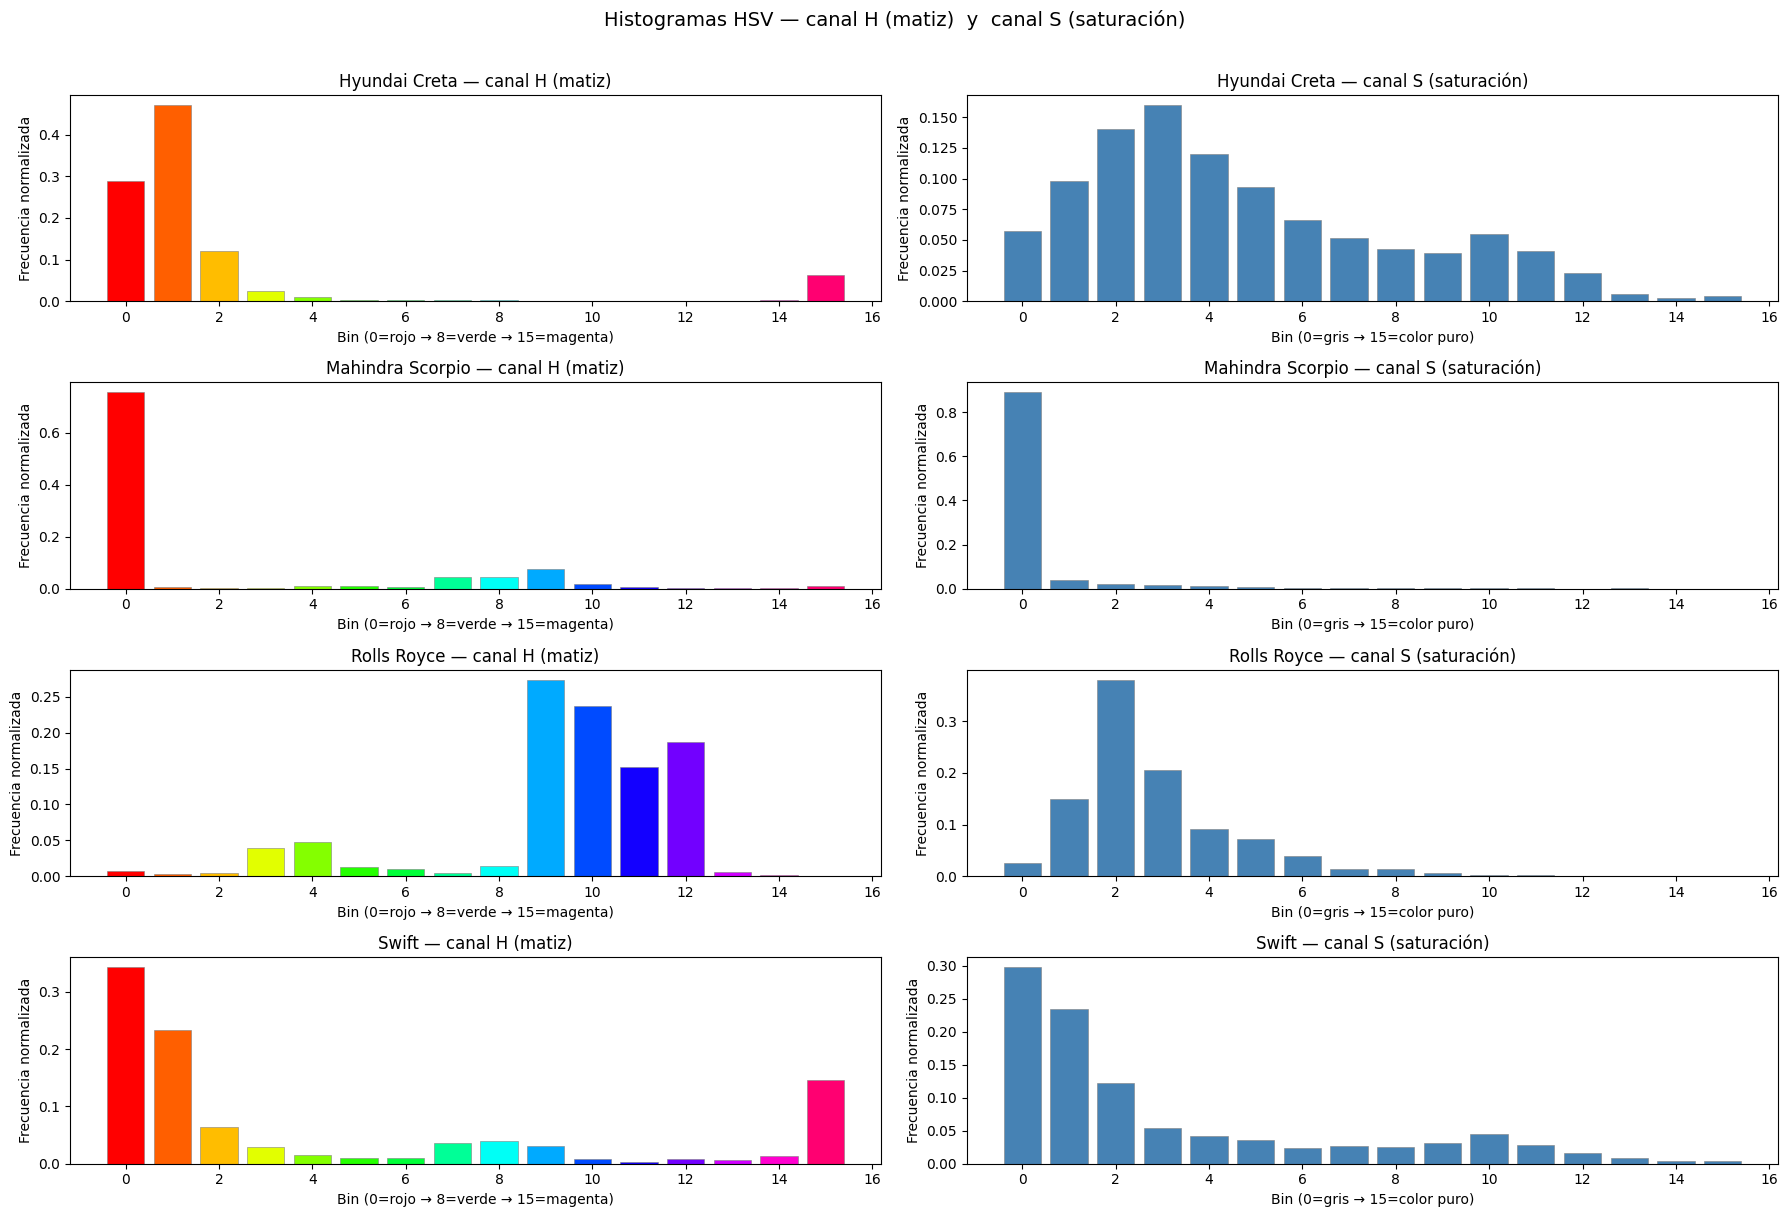

NameError: name 'X_scaled' is not defined

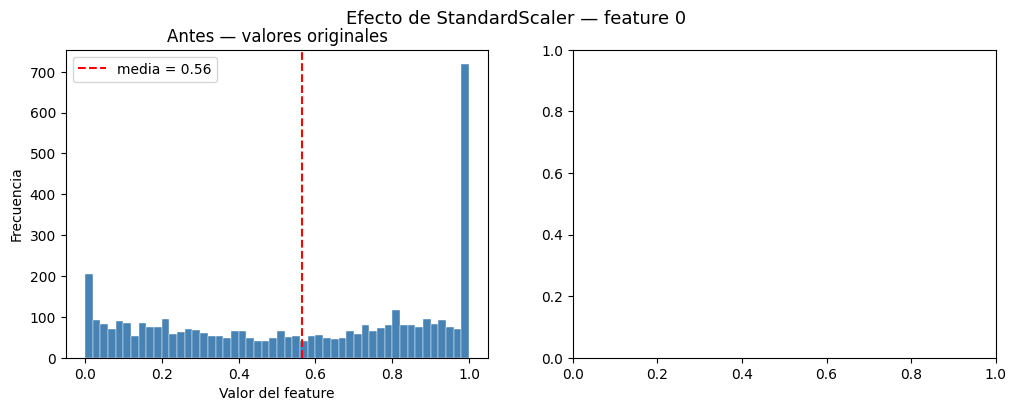

In [ ]:
# @title
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure


MARCAS_EJEMPLO  = clases[:4]      # muestra 4 marcas, cambia el slice si quieres más
IMG_POR_MARCA   = 1               # imágenes por marca para mostrar
FIGSIZE_ANCHO   = 18

def cargar_una_imagen(clase):
    """Devuelve la primera imagen válida de una clase."""
    for current_dir in [train_dir, test_dir]:
        path_clase = os.path.join(current_dir, clase)
        if not os.path.isdir(path_clase):
            continue
        for fname in os.listdir(path_clase):
            img = cv2.imread(os.path.join(path_clase, fname))
            if img is not None:
                return img
    return None

def preprocesar_imagen(img_bgr, size=(128, 128)):
    img = cv2.resize(img_bgr, size)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)


# ============================================================
# BLOQUE 1 — Imagen original vs preprocesada (CLAHE)
# ============================================================

fig, axes = plt.subplots(len(MARCAS_EJEMPLO), 2,
                         figsize=(8, 3.5 * len(MARCAS_EJEMPLO)))
fig.suptitle("Original  vs  CLAHE (preprocesada)", fontsize=14, y=1.01)

for i, clase in enumerate(MARCAS_EJEMPLO):
    img_bgr  = cargar_una_imagen(clase)
    img_rgb  = cv2.cvtColor(cv2.resize(img_bgr, (128, 128)), cv2.COLOR_BGR2RGB)
    img_proc = preprocesar_imagen(img_bgr)
    img_proc_rgb = cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB)

    axes[i, 0].imshow(img_rgb)
    axes[i, 0].set_title(f"{clase} — original")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(img_proc_rgb)
    axes[i, 1].set_title(f"{clase} — CLAHE")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


# ============================================================
# BLOQUE 2 — HOG visualizado sobre la imagen
# ============================================================

fig, axes = plt.subplots(len(MARCAS_EJEMPLO), 2,
                         figsize=(8, 3.5 * len(MARCAS_EJEMPLO)))
fig.suptitle("Imagen preprocesada  vs  HOG", fontsize=14, y=1.01)

for i, clase in enumerate(MARCAS_EJEMPLO):
    img_bgr  = cargar_una_imagen(clase)
    img_proc = preprocesar_imagen(img_bgr)
    gray     = cv2.cvtColor(img_proc, cv2.COLOR_BGR2GRAY)

    _, hog_img = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=True,         # devuelve imagen del HOG además del vector
        feature_vector=True
    )
    # rescale_intensity hace el HOG visible al ojo humano
    hog_img_rescaled = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    axes[i, 0].imshow(cv2.cvtColor(img_proc, cv2.COLOR_BGR2RGB))
    axes[i, 0].set_title(f"{clase} — preprocesada")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(hog_img_rescaled, cmap='gray')
    axes[i, 1].set_title(f"{clase} — HOG")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


# ============================================================
# BLOQUE 3 — Histogramas H y S del espacio HSV
# ============================================================

fig, axes = plt.subplots(len(MARCAS_EJEMPLO), 2,
                         figsize=(FIGSIZE_ANCHO, 3 * len(MARCAS_EJEMPLO)))
fig.suptitle("Histogramas HSV — canal H (matiz)  y  canal S (saturación)",
             fontsize=14, y=1.01)

for i, clase in enumerate(MARCAS_EJEMPLO):
    img_bgr  = cargar_una_imagen(clase)
    img_proc = preprocesar_imagen(img_bgr)
    hsv      = cv2.cvtColor(img_proc, cv2.COLOR_BGR2HSV)

    h_hist = cv2.calcHist([hsv], [0], None, [16], [0, 180]).flatten()
    s_hist = cv2.calcHist([hsv], [1], None, [16], [0, 256]).flatten()
    h_hist /= h_hist.sum() + 1e-7
    s_hist /= s_hist.sum() + 1e-7

    # Canal H — colores reales del matiz para cada bin
    colores_h = [plt.cm.hsv(b / 16) for b in range(16)]
    axes[i, 0].bar(range(16), h_hist, color=colores_h, edgecolor='gray', linewidth=0.4)
    axes[i, 0].set_title(f"{clase} — canal H (matiz)")
    axes[i, 0].set_xlabel("Bin (0=rojo → 8=verde → 15=magenta)")
    axes[i, 0].set_ylabel("Frecuencia normalizada")

    axes[i, 1].bar(range(16), s_hist, color='steelblue', edgecolor='gray', linewidth=0.4)
    axes[i, 1].set_title(f"{clase} — canal S (saturación)")
    axes[i, 1].set_xlabel("Bin (0=gris → 15=color puro)")
    axes[i, 1].set_ylabel("Frecuencia normalizada")

plt.tight_layout()
plt.show()


# ============================================================
# BLOQUE 4 — Cómo cambian los datos con StandardScaler
# distribución de un feature antes y después del escalado
# ============================================================

FEATURE_IDX = 0   # índice del feature a visualizar, cambia para ver otros

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Efecto de StandardScaler — feature {FEATURE_IDX}", fontsize=13)

axes[0].hist(X[:, FEATURE_IDX], bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title("Antes — valores originales")
axes[0].set_xlabel("Valor del feature")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(X[:, FEATURE_IDX].mean(), color='red', linestyle='--', label=f"media = {X[:, FEATURE_IDX].mean():.2f}")
axes[0].legend()

axes[1].hist(X_scaled[:, FEATURE_IDX], bins=50, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title("Después — StandardScaler (media=0, std=1)")
axes[1].set_xlabel("Valor escalado")
axes[1].set_ylabel("Frecuencia")
axes[1].axvline(0, color='red', linestyle='--', label="media = 0")
axes[1].legend()

plt.tight_layout()
plt.show()


# ============================================================
# BLOQUE 5 — PCA: varianza explicada acumulada
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("PCA — varianza explicada", fontsize=13)

varianza_acum = np.cumsum(pca.explained_variance_ratio_)

axes[0].plot(range(1, len(varianza_acum) + 1), varianza_acum,
             color='steelblue', linewidth=1.8)
axes[0].axhline(0.95, color='red',    linestyle='--', label='95% varianza')
axes[0].axhline(0.90, color='orange', linestyle='--', label='90% varianza')
axes[0].axvline(120,  color='green',  linestyle='--', label='n=120 (el que usas)')
axes[0].set_title("Varianza acumulada vs número de componentes")
axes[0].set_xlabel("Número de componentes PCA")
axes[0].set_ylabel("Varianza explicada acumulada")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(range(1, 31), pca.explained_variance_ratio_[:30],
            color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].set_title("Varianza de los primeros 30 componentes")
axes[1].set_xlabel("Componente")
axes[1].set_ylabel("Varianza explicada")
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# ============================================================
# BLOQUE 6 — PCA: dispersión de clases en los 2 primeros componentes
# permite ver si las marcas son separables en el espacio PCA
# ============================================================

colores = plt.cm.tab20(np.linspace(0, 1, len(clases)))

fig, ax = plt.subplots(figsize=(12, 8))
for idx_clase, clase in enumerate(encoder.classes_):
    mask = y_enc == idx_clase
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=clase,
        color=colores[idx_clase],
        alpha=0.5,
        s=15,
        edgecolors='none'
    )

ax.set_title("Dispersión de marcas en los 2 primeros componentes PCA")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left',
          fontsize=8, markerscale=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Comparación de modelos segun su rendimiento

Instancia de imagenes_reales

Definición de las funciones:

Cross validation personalizado con augmentation solo en train

Entrenamiento de un unico modelo con solo augmentation en train

Nota: solo usa PCA en GNB


In [ ]:
# @title
import cv2
import os
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================================================
# PASO 1 — Cargar imágenes
# ============================================================

imagenes_reales = []

for current_dir in [train_dir, test_dir]:
    for clase in clases:
        path_clase = os.path.join(current_dir, clase)
        if not os.path.isdir(path_clase):
            continue
        for fname in os.listdir(path_clase):
            img = cv2.imread(os.path.join(path_clase, fname))
            if img is not None:
                imagenes_reales.append((img, clase))

print(f"Total imágenes reales: {len(imagenes_reales)}")
print(f"Distribución: {Counter([c for _, c in imagenes_reales])}")

encoder = LabelEncoder()
encoder.fit(clases)

y_reales = encoder.transform([clase for _, clase in imagenes_reales])


# ============================================================
# PASO 2 — Augmentation
# ============================================================

datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

def augmentar_y_balancear(imagenes_con_etiquetas):
    conteo   = Counter([c for _, c in imagenes_con_etiquetas])
    objetivo = max(conteo.values())
    balanceadas = []

    for clase in clases:
        imgs_clase = [img for img, c in imagenes_con_etiquetas if c == clase]
        n_actual   = len(imgs_clase)

        for img in imgs_clase:
            balanceadas.append((img, clase))

        faltantes = objetivo - n_actual
        if faltantes <= 0:
            continue

        imgs_arr  = np.array([cv2.resize(im, (128, 128)) for im in imgs_clase])
        generados = 0
        for batch in datagen.flow(imgs_arr, batch_size=4, shuffle=True):
            for img_aug in batch:
                balanceadas.append((img_aug.astype(np.uint8), clase))
                generados += 1
                if generados >= faltantes:
                    break
            if generados >= faltantes:
                break

    return balanceadas


def extraer_features_lista(imagenes_con_etiquetas):
    X_lista, y_lista = [], []
    for img, clase in imagenes_con_etiquetas:
        img_proc = preprocesar_imagen(img)
        feats    = extraer_caracteristicas(img_proc)
        X_lista.append(feats)
        y_lista.append(clase)
    return np.array(X_lista), encoder.transform(y_lista)


# ============================================================
# FUNCIÓN 1 — Entrenar y evaluar UN solo modelo
#             con su propia partición train/test
# ============================================================

def entrenar_modelo(modelo, test_size=0.2, usar_pca=True,
                    n_components=120, verbose=True):
    """
    Separa imágenes reales en train y test.
    Augmentation solo sobre train.
    Entrena y evalúa el modelo una sola vez.

    Parámetros:
        modelo       : clasificador sklearn
        test_size    : proporción para test  (default 0.2 = 80/20)
        usar_pca     : aplica PCA antes del clasificador
        n_components : componentes PCA si usar_pca=True
    """

    # Separar índices — shuffle=True mezcla antes de partir
    idx = np.arange(len(imagenes_reales))
    idx_train, idx_test = train_test_split(
        idx,
        test_size=test_size,
        stratify=y_reales,
        shuffle=True,          # mezcla antes de separar
        random_state=42
    )

    imgs_train_reales = [imagenes_reales[i] for i in idx_train]
    imgs_test_reales  = [imagenes_reales[i] for i in idx_test]

    if verbose:
        print(f"Train real: {len(imgs_train_reales)} | Test real: {len(imgs_test_reales)}")

    # Augmentation solo en train
    imgs_train_aumentadas = augmentar_y_balancear(imgs_train_reales)

    if verbose:
        print(f"Train aumentado: {len(imgs_train_aumentadas)}")
        print(f"Distribución train: {Counter([c for _, c in imgs_train_aumentadas])}")

    # Extraer features
    X_train, y_train = extraer_features_lista(imgs_train_aumentadas)
    X_test,  y_test  = extraer_features_lista(imgs_test_reales)

    # Scaler — fit solo sobre train
    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test  = sc.transform(X_test)

    # PCA opcional — fit solo sobre train
    if usar_pca:
        pc = PCA(n_components=n_components, whiten=True, random_state=42)
        X_train = pc.fit_transform(X_train)
        X_test  = pc.transform(X_test)

    # Entrenar
    modelo.fit(X_train, y_train)

    # Evaluar
    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1  = f1_score(y_test,  y_pred, average='macro', zero_division=0)

    if verbose:
        print(f"\nResultados sobre test real:")
        print(f"  Accuracy : {acc:.3f}")
        print(f"  Recall   : {rec:.3f}")
        print(f"  F1-Score : {f1:.3f}")

    return {'accuracy': acc, 'recall': rec, 'f1': f1}


# ============================================================
# FUNCIÓN 2 — Cross validation con augmentation limpia
# ============================================================

def cross_val_con_augmentation(modelo, n_splits=5, usar_pca=True,
                                n_components=120, verbose=True):
    skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    indices = np.arange(len(imagenes_reales))

    scores_acc, scores_rec, scores_f1 = [], [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(indices, y_reales)):

        imgs_train_reales = [imagenes_reales[i] for i in train_idx]
        imgs_val_reales   = [imagenes_reales[i] for i in val_idx]

        imgs_train_aumentadas = augmentar_y_balancear(imgs_train_reales)

        X_tr,  y_tr  = extraer_features_lista(imgs_train_aumentadas)
        X_val, y_val = extraer_features_lista(imgs_val_reales)

        sc = StandardScaler()
        X_tr  = sc.fit_transform(X_tr)
        X_val = sc.transform(X_val)

        if usar_pca:
            pc = PCA(n_components=n_components, whiten=True, random_state=42)
            X_tr  = pc.fit_transform(X_tr)
            X_val = pc.transform(X_val)

        modelo.fit(X_tr, y_tr)
        y_pred = modelo.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred, average='macro', zero_division=0)
        f1  = f1_score(y_val,  y_pred,   average='macro', zero_division=0)

        scores_acc.append(acc)
        scores_rec.append(rec)
        scores_f1.append(f1)

        if verbose:
            print(f"  Fold {fold+1} — Acc: {acc:.3f} | Rec: {rec:.3f} | F1: {f1:.3f}"
                  f"  (train: {len(imgs_train_aumentadas)} | val: {len(imgs_val_reales)})")

    resultados = {
        'accuracy': np.array(scores_acc),
        'recall':   np.array(scores_rec),
        'f1':       np.array(scores_f1),
    }

    if verbose:
        print(f"\n  Accuracy : {resultados['accuracy'].mean():.3f} ± {resultados['accuracy'].std():.3f}")
        print(f"  Recall   : {resultados['recall'].mean():.3f}   ± {resultados['recall'].std():.3f}")
        print(f"  F1-Score : {resultados['f1'].mean():.3f}     ± {resultados['f1'].std():.3f}")

    return resultados

Total imágenes reales: 4165
Distribución: Counter({'Audi': 1013, 'Toyota Innova': 965, 'Tata Safari': 547, 'Swift': 526, 'Mahindra Scorpio': 391, 'Rolls Royce': 385, 'Hyundai Creta': 338})


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

Definicion de la función para entrenar un modelo y obtener sus metricas

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

def metricas_modelo(modelo, test_size=0.2, usar_pca=True,
                    n_components=120, nombre_modelo='Modelo'):
    """
    Entrena un modelo y muestra accuracy, f1, recall y especificidad
    por clase y en promedio.
    """

    # --- Partición y augmentation ---
    idx = np.arange(len(imagenes_reales))
    idx_train, idx_test = train_test_split(
        idx, test_size=test_size, stratify=y_reales,
        shuffle=True, random_state=42
    )

    imgs_train = augmentar_y_balancear([imagenes_reales[i] for i in idx_train])
    imgs_test  = [imagenes_reales[i] for i in idx_test]

    X_train, y_train = extraer_features_lista(imgs_train)
    X_test,  y_test  = extraer_features_lista(imgs_test)

    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test  = sc.transform(X_test)

    if usar_pca:
        pc = PCA(n_components=n_components, whiten=True, random_state=42)
        X_train = pc.fit_transform(X_train)
        X_test  = pc.transform(X_test)

    # --- Entrenar y predecir ---
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # --- Métricas globales ---
    acc    = accuracy_score(y_test, y_pred)
    f1_mac = f1_score(y_test, y_pred, average='macro',  zero_division=0)
    rec    = recall_score(y_test, y_pred, average='macro', zero_division=0)

    # --- Especificidad por clase ---
    # especificidad = TN / (TN + FP)
    # la matriz de confusion nos da lo necesario para calcularla por clase
    cm      = confusion_matrix(y_test, y_pred)
    n_clases_local = cm.shape[0]
    especificidades = []

    for i in range(n_clases_local):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP
        esp = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        especificidades.append(esp)

    esp_macro = np.mean(especificidades)

    # --- F1 por clase ---
    f1_por_clase = f1_score(y_test, y_pred, average=None, zero_division=0)

    # --- Recall por clase ---
    rec_por_clase = recall_score(y_test, y_pred, average=None, zero_division=0)

    # ============================================================
    # TABLA POR CLASE
    # ============================================================

    nombres_clases = encoder.classes_
    print(f"\n{'='*65}")
    print(f"  {nombre_modelo}")
    print(f"{'='*65}")
    print(f"{'Clase':<20} {'F1':>8} {'Recall':>8} {'Especif.':>10}")
    print(f"{'-'*65}")

    for i, clase in enumerate(nombres_clases):
        print(f"{clase:<20} {f1_por_clase[i]:>8.3f} "
              f"{rec_por_clase[i]:>8.3f} {especificidades[i]:>10.3f}")

    print(f"{'-'*65}")
    print(f"{'PROMEDIO MACRO':<20} {f1_mac:>8.3f} {rec:>8.3f} {esp_macro:>10.3f}")
    print(f"{'ACCURACY':<20} {acc:>8.3f}")
    print(f"{'='*65}")

    # ============================================================
    # GRÁFICA
    # ============================================================

    x      = np.arange(len(nombres_clases))
    ancho  = 0.25

    fig, ax = plt.subplots(figsize=(max(12, len(nombres_clases)), 5))

    b1 = ax.bar(x - ancho, f1_por_clase,   ancho, label='F1-Score',      color='steelblue',      edgecolor='white')
    b2 = ax.bar(x,         rec_por_clase,  ancho, label='Recall',         color='coral',          edgecolor='white')
    b3 = ax.bar(x + ancho, especificidades, ancho, label='Especificidad', color='mediumseagreen', edgecolor='white')

    for barras in [b1, b2, b3]:
        for barra in barras:
            alto = barra.get_height()
            ax.text(barra.get_x() + barra.get_width() / 2,
                    alto + 0.01, f'{alto:.2f}',
                    ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(nombres_clases, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Puntuación')
    ax.set_title(f'{nombre_modelo} — F1, Recall y Especificidad por clase')
    ax.set_ylim(0, 1.12)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    plt.tight_layout()
    plt.show()

    return {
        'accuracy':        acc,
        'f1_macro':        f1_mac,
        'recall_macro':    rec,
        'especif_macro':   esp_macro,
        'f1_por_clase':    f1_por_clase,
        'recall_por_clase': rec_por_clase,
        'especif_por_clase': np.array(especificidades)
    }

In [ ]:
entrenar_modelo(SVC(kernel='rbf', C=100, gamma='scale',
                                random_state=42), usar_pca=False)

Train real: 3332 | Test real: 833
Train aumentado: 5670
Distribución train: Counter({'Hyundai Creta': 810, 'Mahindra Scorpio': 810, 'Rolls Royce': 810, 'Swift': 810, 'Toyota Innova': 810, 'Tata Safari': 810, 'Audi': 810})

Resultados sobre test real:
  Accuracy : 0.677
  Recall   : 0.636
  F1-Score : 0.638


{'accuracy': 0.6770708283313326,
 'recall': 0.6356708962913495,
 'f1': 0.6376014203627921}


  SVM
Clase                      F1   Recall   Especif.
-----------------------------------------------------------------
Audi                    0.706    0.759      0.875
Hyundai Creta           0.521    0.456      0.974
Mahindra Scorpio        0.621    0.705      0.942
Rolls Royce             0.453    0.377      0.971
Swift                   0.718    0.714      0.960
Tata Safari             0.780    0.780      0.967
Toyota Innova           0.770    0.756      0.938
-----------------------------------------------------------------
PROMEDIO MACRO          0.653    0.650      0.947
ACCURACY                0.690


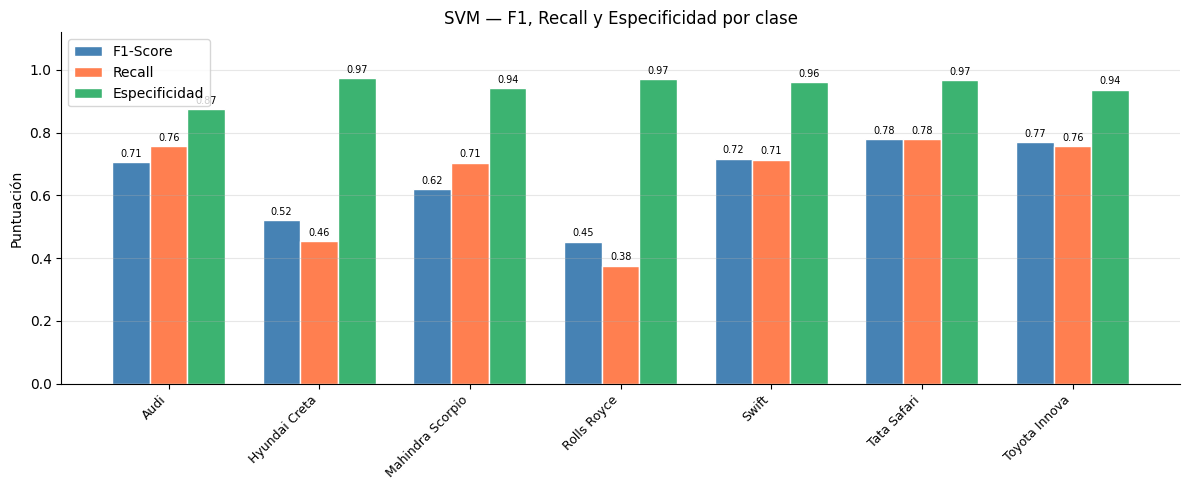

In [ ]:
r_svm = metricas_modelo(SVC(kernel='rbf', C=100, gamma='scale',
                             class_weight='balanced', random_state=42),
                         usar_pca=False, nombre_modelo='SVM')

GNB

In [ ]:
print("===== NAIVE BAYES =====")
scores_nb = cross_val_con_augmentation(
    GaussianNB(),
    n_splits=5,
    usar_pca=True,
    n_components=120
)



===== NAIVE BAYES =====
  Fold 1 — Acc: 0.435 | Rec: 0.372 | F1: 0.381  (train: 5677 | val: 833)
  Fold 2 — Acc: 0.415 | Rec: 0.343 | F1: 0.358  (train: 5677 | val: 833)
  Fold 3 — Acc: 0.441 | Rec: 0.377 | F1: 0.394  (train: 5670 | val: 833)
  Fold 4 — Acc: 0.448 | Rec: 0.364 | F1: 0.377  (train: 5670 | val: 833)
  Fold 5 — Acc: 0.426 | Rec: 0.359 | F1: 0.369  (train: 5670 | val: 833)

  Accuracy : 0.433 ± 0.011
  Recall   : 0.363   ± 0.012
  F1-Score : 0.376     ± 0.012


DT

In [ ]:
print("\n===== DECISION TREE =====")
scores_dt = cross_val_con_augmentation(
    DecisionTreeClassifier(max_depth=15, min_samples_leaf=5,
                           max_features='sqrt', class_weight='balanced',
                           random_state=42),
    usar_pca=False
)




===== DECISION TREE =====
  Fold 1 — Acc: 0.377 | Rec: 0.365 | F1: 0.355  (train: 5677 | val: 833)
  Fold 2 — Acc: 0.382 | Rec: 0.377 | F1: 0.364  (train: 5677 | val: 833)
  Fold 3 — Acc: 0.379 | Rec: 0.379 | F1: 0.361  (train: 5670 | val: 833)
  Fold 4 — Acc: 0.373 | Rec: 0.369 | F1: 0.356  (train: 5670 | val: 833)
  Fold 5 — Acc: 0.341 | Rec: 0.340 | F1: 0.331  (train: 5670 | val: 833)

  Accuracy : 0.370 ± 0.015
  Recall   : 0.366   ± 0.014
  F1-Score : 0.354     ± 0.012


RF

In [ ]:
print("\n===== RANDOM FOREST =====")
scores_rf = cross_val_con_augmentation(
    RandomForestClassifier(n_estimators=300, max_features='sqrt',
                           class_weight='balanced', n_jobs=-1,
                           random_state=42),
    usar_pca=False
)




===== RANDOM FOREST =====
  Fold 1 — Acc: 0.637 | Rec: 0.590 | F1: 0.595  (train: 5677 | val: 833)
  Fold 2 — Acc: 0.637 | Rec: 0.586 | F1: 0.599  (train: 5677 | val: 833)
  Fold 3 — Acc: 0.629 | Rec: 0.583 | F1: 0.591  (train: 5670 | val: 833)
  Fold 4 — Acc: 0.616 | Rec: 0.565 | F1: 0.580  (train: 5670 | val: 833)
  Fold 5 — Acc: 0.640 | Rec: 0.587 | F1: 0.596  (train: 5670 | val: 833)

  Accuracy : 0.632 ± 0.009
  Recall   : 0.582   ± 0.009
  F1-Score : 0.592     ± 0.007


SVM

In [ ]:
print("\n===== SVM =====")
scores_svm = cross_val_con_augmentation(
    SVC(kernel='rbf', C=100, gamma='scale', class_weight='balanced',
        random_state=42),
    usar_pca=False
)


===== SVM =====
  Fold 1 — Acc: 0.714 | Rec: 0.691 | F1: 0.689  (train: 5677 | val: 833)
  Fold 2 — Acc: 0.687 | Rec: 0.647 | F1: 0.653  (train: 5677 | val: 833)
  Fold 3 — Acc: 0.700 | Rec: 0.667 | F1: 0.668  (train: 5670 | val: 833)
  Fold 4 — Acc: 0.719 | Rec: 0.693 | F1: 0.696  (train: 5670 | val: 833)
  Fold 5 — Acc: 0.703 | Rec: 0.668 | F1: 0.672  (train: 5670 | val: 833)

  Accuracy : 0.705 ± 0.011
  Recall   : 0.673   ± 0.017
  F1-Score : 0.676     ± 0.016


Deep learning

Shape X: (4165, 200, 200, 3)
Shape y: (4165,)
Train: (3332, 200, 200, 3) | Test: (833, 200, 200, 3)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 120000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2000)           │   240,002,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,049,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,748,759 (926.01 MB)

 Trainable params: 242,748,759 (926.01 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 19s 113ms/step - accuracy: 0.2215 - loss: 11.4729 - val_accuracy: 0.2665 - val_loss: 1.8210
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.3190 - loss: 1.7802 - val_accuracy: 0.3109 - val_loss: 1.8276
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.3595 - loss: 1.7005 - val_accuracy: 0.2761 - val_loss: 2.3352
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.3529 - loss: 1.7049 - val_accuracy: 0.3277 - val_loss: 1.8140
Epoch 5/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.4100 - loss: 1.6033 - val_accuracy: 0.4010 - val_loss: 1.6550
Epoch 6/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.4457 - loss: 1.5172 - val_accuracy: 0.4058 - val_loss: 1.6047
Epoch 7/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.4751 - loss: 1.4492 - val_accuracy: 0.3950 - val_loss: 1.6595
Epoch 8/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 56ms/step - accuracy: 0.4829 - loss: 1.4258 - val_a

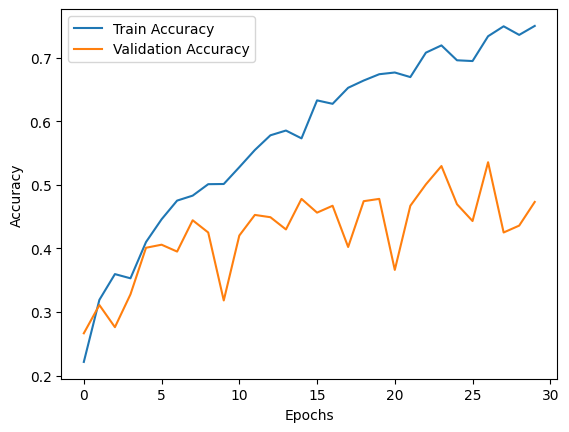

In [ ]:
# @title
import cv2
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


X = []
y = []

for img, clase in imagenes_reales:
    img_rgb = cv2.cvtColor(cv2.resize(img, (200, 200)), cv2.COLOR_BGR2RGB)
    img_f   = img_rgb.astype(np.float32) / 255.0
    X.append(img_f)
    y.append(clase)

X = np.array(X)   # (N, 200, 200, 3)
y = np.array(encoder.transform(y))   # (N,) enteros — 0, 1, 2...

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


n_clases = len(clases)

model = Sequential([
    Flatten(input_shape=(200, 200, 3)),   # (200, 200, 3)
    Dense(2000, activation='relu'),
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64,  activation='relu'),
    Dense(n_clases, activation='softmax') # una probabilidad por marca
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # funciona con y como enteros, sin one-hot
    metrics=['accuracy']
)

model.summary()



history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)


plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Modelos no supervisados


Preparación de los datos

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Extraer features sin augmentation
X_lista, y_lista = [], []

for img, clase in imagenes_reales:
    img_proc = preprocesar_imagen(img)
    feats    = extraer_caracteristicas(img_proc)
    X_lista.append(feats)
    y_lista.append(clase)

X_raw = np.array(X_lista)
y_raw = encoder.transform(y_lista)

# Escalar
sc   = StandardScaler()
X_sc = sc.fit_transform(X_raw)

# PCA para clustering — menos dimensiones mejora las distancias
pca  = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_sc)

# PCA 2D solo para visualizaciones
pca_2d   = PCA(n_components=2, random_state=42)
X_vis_2d = pca_2d.fit_transform(X_sc)

nombres_clases = encoder.classes_
n_clases       = len(nombres_clases)
colores        = plt.cm.tab20(np.linspace(0, 1, n_clases))

print(f"Features originales : {X_raw.shape}")
print(f"Después de PCA 95%   : {X_pca.shape}")
print(f"Número de clases    : {n_clases}")

Features originales : (4165, 8132)
Después de PCA 95%   : (4165, 1407)
Número de clases    : 7


Metodo del codo

Calculando métricas para distintos valores de K...
  K= 2 | Inercia:   30652582 | Silueta: 0.094 | Davies-Bouldin: 3.444
  K= 3 | Inercia:   30151835 | Silueta: 0.023 | Davies-Bouldin: 5.736
  K= 4 | Inercia:   29750914 | Silueta: 0.023 | Davies-Bouldin: 5.447
  K= 5 | Inercia:   29420938 | Silueta: 0.025 | Davies-Bouldin: 5.133
  K= 6 | Inercia:   29160154 | Silueta: 0.023 | Davies-Bouldin: 5.177
  K= 7 | Inercia:   28894508 | Silueta: 0.026 | Davies-Bouldin: 4.733
  K= 8 | Inercia:   28669104 | Silueta: 0.024 | Davies-Bouldin: 4.875
  K= 9 | Inercia:   28514876 | Silueta: 0.020 | Davies-Bouldin: 4.981
  K=10 | Inercia:   28377078 | Silueta: 0.022 | Davies-Bouldin: 4.875
  K=11 | Inercia:   28247419 | Silueta: 0.019 | Davies-Bouldin: 4.853
  K=12 | Inercia:   28124066 | Silueta: 0.023 | Davies-Bouldin: 4.898


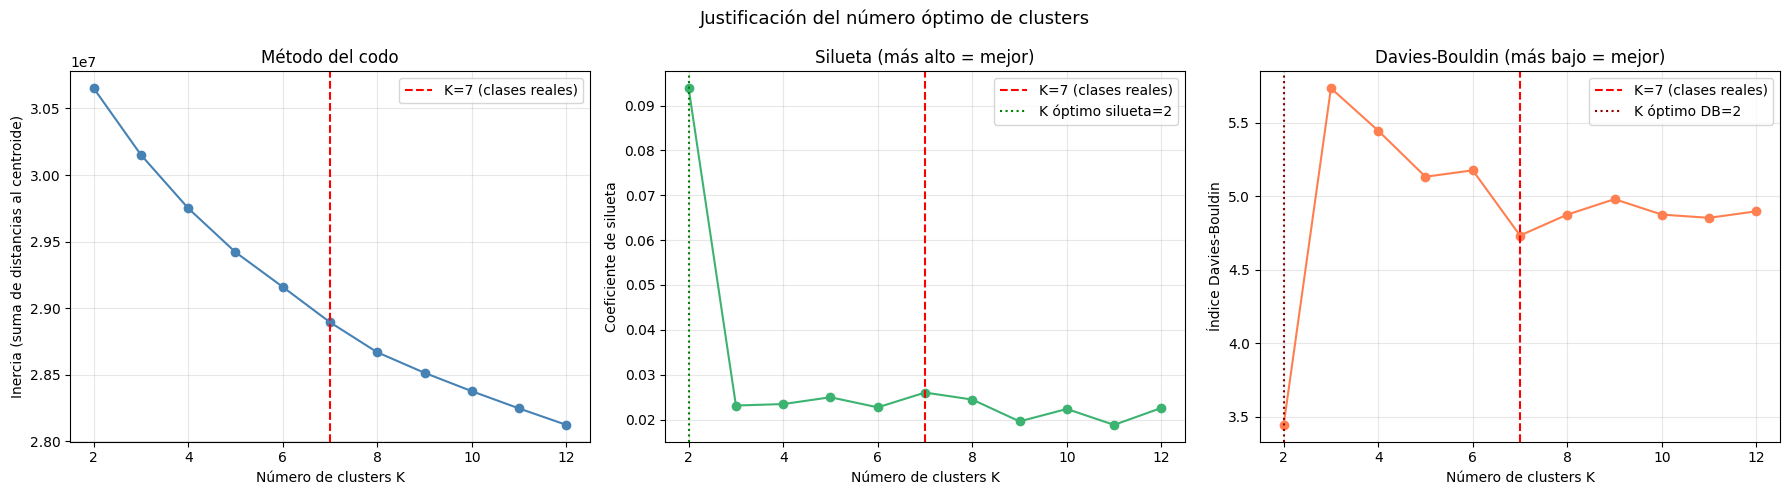


K seleccionado: 7 (igual al número de clases reales)
Silueta en K=7: 0.026
Davies-Bouldin en K=7: 4.733


In [ ]:
# @title
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

inercias    = []
siluetas    = []
davies      = []
rango_k     = range(2, n_clases + 6)   # prueba desde 2 hasta n_clases+5

print("Calculando métricas para distintos valores de K...")

for k in rango_k:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=42)
    labels = km.fit_predict(X_pca)

    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_pca, labels, sample_size=1000,
                                     random_state=42))
    davies.append(davies_bouldin_score(X_pca, labels))
    print(f"  K={k:>2} | Inercia: {km.inertia_:>10.0f} | "
          f"Silueta: {siluetas[-1]:.3f} | Davies-Bouldin: {davies[-1]:.3f}")

# ============================================================
# Gráfica del codo + métricas de apoyo
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Codo
axes[0].plot(rango_k, inercias, 'o-', color='steelblue', linewidth=1.5)
axes[0].axvline(n_clases, color='red', linestyle='--',
                label=f'K={n_clases} (clases reales)')
axes[0].set_xlabel("Número de clusters K")
axes[0].set_ylabel("Inercia (suma de distancias al centroide)")
axes[0].set_title("Método del codo")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silueta — más alto es mejor
axes[1].plot(rango_k, siluetas, 'o-', color='mediumseagreen', linewidth=1.5)
axes[1].axvline(n_clases, color='red', linestyle='--',
                label=f'K={n_clases} (clases reales)')
axes[1].axvline(siluetas.index(max(siluetas)) + 2, color='green',
                linestyle=':', label=f'K óptimo silueta={siluetas.index(max(siluetas))+2}')
axes[1].set_xlabel("Número de clusters K")
axes[1].set_ylabel("Coeficiente de silueta")
axes[1].set_title("Silueta (más alto = mejor)")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Davies-Bouldin — más bajo es mejor
axes[2].plot(rango_k, davies, 'o-', color='coral', linewidth=1.5)
axes[2].axvline(n_clases, color='red', linestyle='--',
                label=f'K={n_clases} (clases reales)')
axes[2].axvline(davies.index(min(davies)) + 2, color='darkred',
                linestyle=':', label=f'K óptimo DB={davies.index(min(davies))+2}')
axes[2].set_xlabel("Número de clusters K")
axes[2].set_ylabel("Índice Davies-Bouldin")
axes[2].set_title("Davies-Bouldin (más bajo = mejor)")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("Justificación del número óptimo de clusters", fontsize=13)
plt.tight_layout()
plt.show()

k_optimo = n_clases
print(f"\nK seleccionado: {k_optimo} (igual al número de clases reales)")
print(f"Silueta en K={k_optimo}: {siluetas[k_optimo-2]:.3f}")
print(f"Davies-Bouldin en K={k_optimo}: {davies[k_optimo-2]:.3f}")

Kmeans

In [ ]:
# @title
from sklearn.cluster import KMeans
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             accuracy_score, f1_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay)
from scipy.stats import mode

# ============================================================
# Utilidad — mapear clusters a clases reales
# ============================================================

def mapear_clusters(y_true, y_clusters, n_clusters):
    mapeo = {}
    for c in range(n_clusters):
        idx = np.where(y_clusters == c)[0]
        if len(idx) == 0:
            mapeo[c] = -1
            continue
        mapeo[c] = mode(y_true[idx], keepdims=True).mode[0]
    return mapeo

def aplicar_mapeo(y_clusters, mapeo):
    return np.array([mapeo.get(c, -1) for c in y_clusters])

# ============================================================
# Entrenar KMeans
# ============================================================

kmeans = KMeans(
    n_clusters=k_optimo,
    init='k-means++',    # inicialización inteligente — evita mínimos locales
    n_init=20,           # 20 inicializaciones distintas, se queda con la mejor
    max_iter=500,        # iteraciones máximas por inicialización
    random_state=42
)

labels_km = kmeans.fit_predict(X_pca)

# Mapear clusters a clases
mapeo_km  = mapear_clusters(y_raw, labels_km, k_optimo)
y_pred_km = aplicar_mapeo(labels_km, mapeo_km)

# ============================================================
# Métricas
# ============================================================

ari_km  = adjusted_rand_score(y_raw, labels_km)
nmi_km  = normalized_mutual_info_score(y_raw, labels_km)
sil_km  = silhouette_score(X_pca, labels_km, sample_size=1000, random_state=42)
db_km   = davies_bouldin_score(X_pca, labels_km)

mask_km = y_pred_km != -1
acc_km  = accuracy_score(y_raw[mask_km], y_pred_km[mask_km])
f1_km   = f1_score(y_raw[mask_km], y_pred_km[mask_km],
                   average='macro', zero_division=0)
rec_km  = recall_score(y_raw[mask_km], y_pred_km[mask_km],
                       average='macro', zero_division=0)

print("="*55)
print("  KMEANS — MÉTRICAS")
print("="*55)
print(f"ARI              : {ari_km:.3f}  (0=aleatorio, 1=perfecto)")
print(f"NMI              : {nmi_km:.3f}  (0=aleatorio, 1=perfecto)")
print(f"Silueta          : {sil_km:.3f}  (más alto = mejor)")
print(f"Davies-Bouldin   : {db_km:.3f}  (más bajo = mejor)")
print(f"Accuracy mapeada : {acc_km:.3f}")
print(f"F1 macro         : {f1_km:.3f}")
print(f"Recall macro     : {rec_km:.3f}")

# Tamaño de cada cluster
print(f"\nTamaño de clusters:")
for c in range(k_optimo):
    clase_mapeada = nombres_clases[mapeo_km[c]] if mapeo_km[c] != -1 else 'sin mapeo'
    n = np.sum(labels_km == c)
    print(f"  Cluster {c:>2} → {clase_mapeada:<15} ({n} imágenes)")

  KMEANS — MÉTRICAS
ARI              : 0.036  (0=aleatorio, 1=perfecto)
NMI              : 0.041  (0=aleatorio, 1=perfecto)
Silueta          : 0.025  (más alto = mejor)
Davies-Bouldin   : 4.758  (más bajo = mejor)
Accuracy mapeada : 0.320
F1 macro         : 0.124
Recall macro     : 0.192

Tamaño de clusters:
  Cluster  0 → Toyota Innova   (743 imágenes)
  Cluster  1 → Toyota Innova   (248 imágenes)
  Cluster  2 → Audi            (958 imágenes)
  Cluster  3 → Toyota Innova   (216 imágenes)
  Cluster  4 → Audi            (908 imágenes)
  Cluster  5 → Toyota Innova   (277 imágenes)
  Cluster  6 → Audi            (815 imágenes)


DBscan

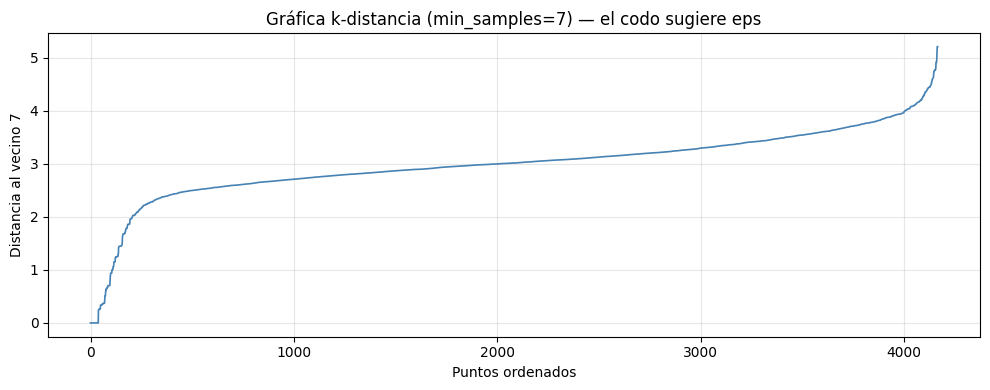

eps sugerido por el codo: 0.23
min_samples seleccionado: 7

Ajusta eps manualmente si los resultados no son buenos:
  Muchos puntos de ruido → aumenta eps
  Un solo cluster grande → reduce eps


In [ ]:
# @title
from sklearn.neighbors import NearestNeighbors

# ============================================================
# Encontrar eps óptimo con la gráfica de distancia al k-ésimo vecino
# el codo de esta curva indica el eps adecuado
# ============================================================

# DBSCAN funciona mejor con menos dimensiones
pca_db   = PCA(n_components=20, whiten=True, random_state=42)
X_db     = pca_db.fit_transform(X_sc)

min_samples = max(5, len(nombres_clases))   # regla: al menos n_clases vecinos

nn = NearestNeighbors(n_neighbors=min_samples, metric='euclidean')
nn.fit(X_db)
distancias, _ = nn.kneighbors(X_db)
distancias_k  = np.sort(distancias[:, -1])   # distancia al k-ésimo vecino

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(distancias_k, color='steelblue', linewidth=1.2)
ax.set_xlabel("Puntos ordenados")
ax.set_ylabel(f"Distancia al vecino {min_samples}")
ax.set_title(f"Gráfica k-distancia (min_samples={min_samples}) — el codo sugiere eps")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Seleccionar eps en el codo — aproximación por la segunda derivada
segunda_deriv = np.diff(distancias_k, n=2)
idx_codo      = np.argmax(segunda_deriv) + 2
eps_sugerido  = round(distancias_k[idx_codo], 2)

print(f"eps sugerido por el codo: {eps_sugerido}")
print(f"min_samples seleccionado: {min_samples}")
print(f"\nAjusta eps manualmente si los resultados no son buenos:")
print(f"  Muchos puntos de ruido → aumenta eps")
print(f"  Un solo cluster grande → reduce eps")

In [ ]:
# @title
from sklearn.cluster import DBSCAN
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             silhouette_score, davies_bouldin_score,
                             accuracy_score, f1_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay)

eps_final        = 2.2
min_samples_final = min_samples

dbscan = DBSCAN(
    eps=eps_final,
    min_samples=min_samples_final,
    metric='euclidean',
    n_jobs=-1
)

labels_db     = dbscan.fit_predict(X_db)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_ruido_db    = np.sum(labels_db == -1)

print(f"Clusters encontrados : {n_clusters_db}  (esperados: {n_clases})")
print(f"Puntos ruido (-1)    : {n_ruido_db} / {len(X_db)} "
      f"({n_ruido_db/len(X_db)*100:.1f}%)")

# ============================================================
# Predecir en todos los puntos usando vecino más cercano
# (DBSCAN no tiene predict nativo)
# ============================================================

mascara_no_ruido  = labels_db != -1
X_db_limpio       = X_db[mascara_no_ruido]
labels_db_limpio  = labels_db[mascara_no_ruido]
y_raw_limpio      = y_raw[mascara_no_ruido]

nn_pred = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn_pred.fit(X_db_limpio)
_, vecinos   = nn_pred.kneighbors(X_db)
labels_todos = labels_db_limpio[vecinos.flatten()]

# Mapear clusters a clases
if n_clusters_db > 0:
    mapeo_db  = mapear_clusters(y_raw_limpio, labels_db_limpio, n_clusters_db)
    y_pred_db = aplicar_mapeo(labels_todos, mapeo_db)

    mask_db  = y_pred_db != -1
    acc_db   = accuracy_score(y_raw[mask_db], y_pred_db[mask_db])
    f1_db    = f1_score(y_raw[mask_db], y_pred_db[mask_db],
                        average='macro', zero_division=0)
    rec_db   = recall_score(y_raw[mask_db], y_pred_db[mask_db],
                            average='macro', zero_division=0)

    # Silueta solo si hay más de 1 cluster y menos de n-1 clusters
    if 1 < n_clusters_db < len(X_db) - 1 and mascara_no_ruido.sum() > 1:
        sil_db = silhouette_score(X_db_limpio, labels_db_limpio,
                                  sample_size=1000, random_state=42)
        db_db  = davies_bouldin_score(X_db_limpio, labels_db_limpio)
    else:
        sil_db = db_db = float('nan')

    ari_db = adjusted_rand_score(y_raw, labels_todos)
    nmi_db = normalized_mutual_info_score(y_raw, labels_todos)

    print("\n" + "="*55)
    print("  DBSCAN — MÉTRICAS")
    print("="*55)
    print(f"ARI              : {ari_db:.3f}")
    print(f"NMI              : {nmi_db:.3f}")
    print(f"Silueta          : {sil_db:.3f}" if not np.isnan(sil_db) else "Silueta : N/A")
    print(f"Davies-Bouldin   : {db_db:.3f}"  if not np.isnan(db_db)  else "Davies-Bouldin : N/A")
    print(f"Accuracy mapeada : {acc_db:.3f}")
    print(f"F1 macro         : {f1_db:.3f}")
    print(f"Recall macro     : {rec_db:.3f}")
else:
    print("DBSCAN no encontró clusters válidos — ajusta eps y min_samples")
    acc_db = f1_db = rec_db = ari_db = nmi_db = sil_db = db_db = 0.0

Clusters encontrados : 39  (esperados: 7)
Puntos ruido (-1)    : 3783 / 4165 (90.8%)

  DBSCAN — MÉTRICAS
ARI              : 0.009
NMI              : 0.070
Silueta          : 0.629
Davies-Bouldin   : 0.684
Accuracy mapeada : 0.273
F1 macro         : 0.175
Recall macro     : 0.213


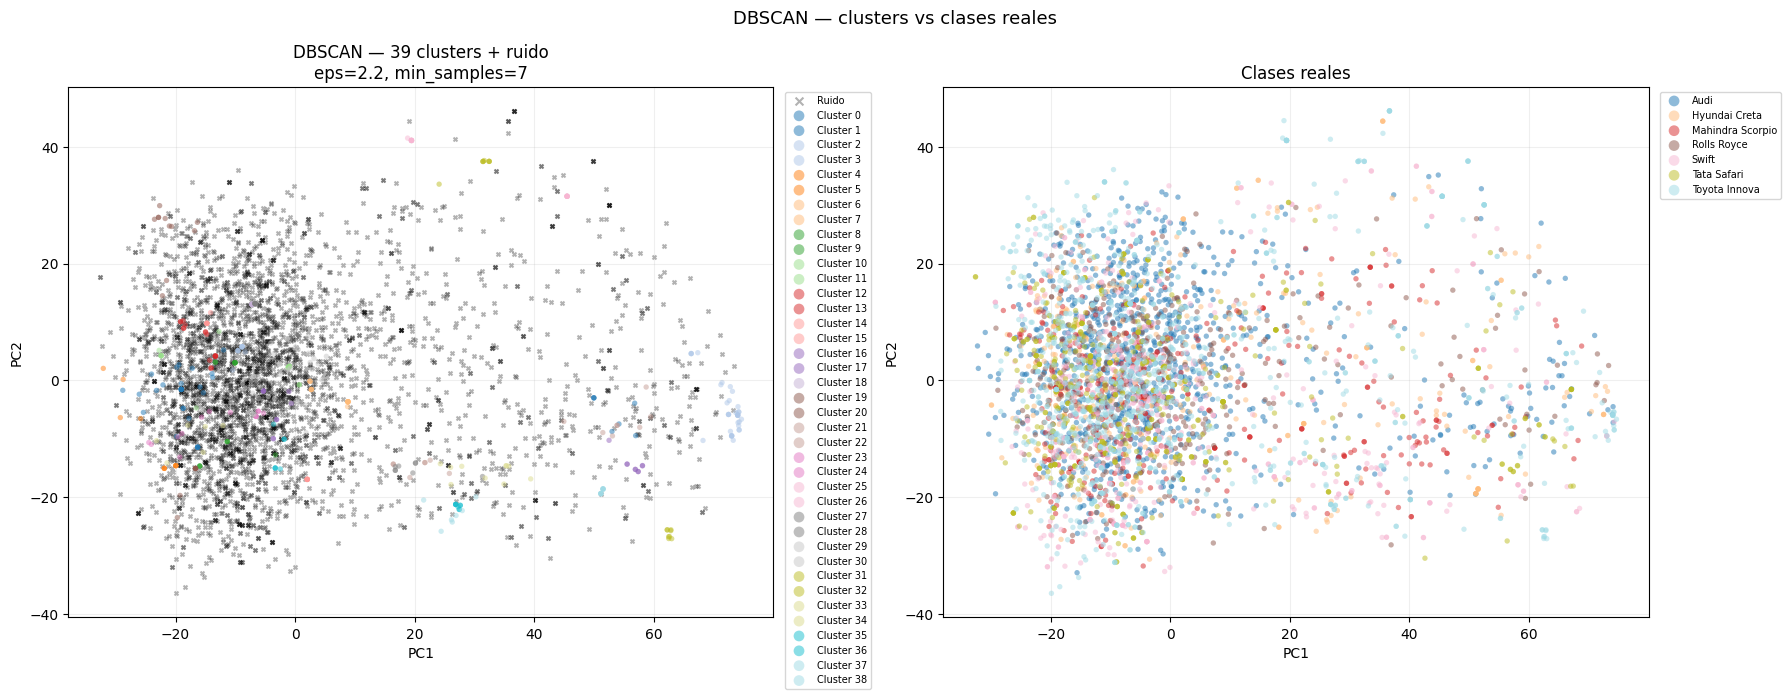

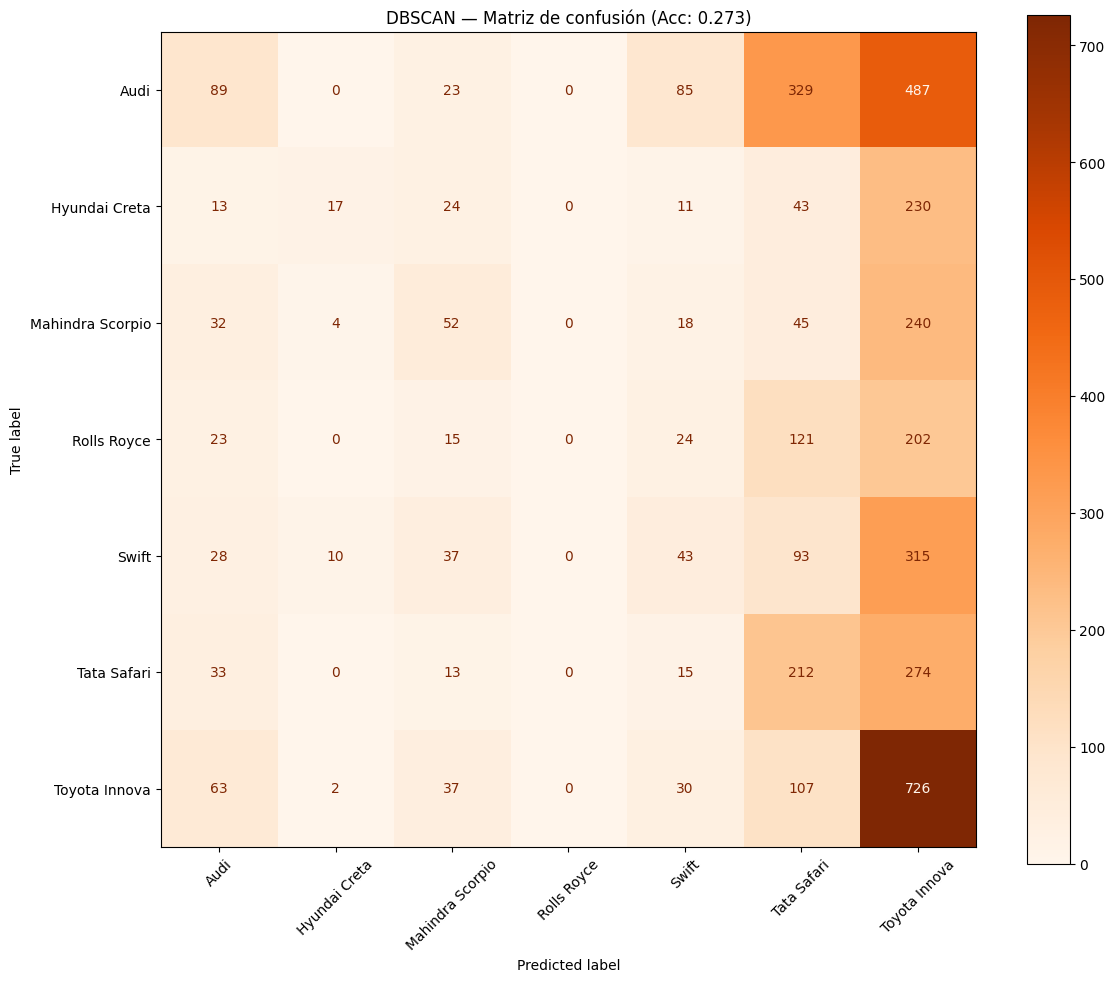

In [ ]:
# @title
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Clusters DBSCAN
colores_db = plt.cm.tab20(np.linspace(0, 1, max(n_clusters_db, 1)))

for c in sorted(set(labels_db)):
    mask  = labels_db == c
    if c == -1:
        axes[0].scatter(X_vis_2d[mask, 0], X_vis_2d[mask, 1],
                        color='black', label='Ruido',
                        alpha=0.3, s=8, marker='x')
    else:
        axes[0].scatter(X_vis_2d[mask, 0], X_vis_2d[mask, 1],
                        color=colores_db[c % len(colores_db)],
                        label=f'Cluster {c}',
                        alpha=0.5, s=15, edgecolors='none')

axes[0].set_title(f"DBSCAN — {n_clusters_db} clusters + ruido\n"
                  f"eps={eps_final}, min_samples={min_samples_final}")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=7, markerscale=2,
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[0].grid(alpha=0.2)

# Clases reales
for i, clase in enumerate(nombres_clases):
    mask = y_raw == i
    axes[1].scatter(X_vis_2d[mask, 0], X_vis_2d[mask, 1],
                    color=colores[i], label=clase,
                    alpha=0.5, s=15, edgecolors='none')

axes[1].set_title("Clases reales")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=7, markerscale=2,
               bbox_to_anchor=(1.01, 1), loc='upper left')
axes[1].grid(alpha=0.2)

plt.suptitle("DBSCAN — clusters vs clases reales", fontsize=13)
plt.tight_layout()
plt.show()

# Matriz de confusión
if n_clusters_db > 0 and mask_db.sum() > 0:
    fig, ax = plt.subplots(figsize=(12, 10))
    cm_db = confusion_matrix(y_raw[mask_db], y_pred_db[mask_db])
    ConfusionMatrixDisplay(cm_db, display_labels=nombres_clases).plot(
        ax=ax, colorbar=True, xticks_rotation=45, cmap='Oranges'
    )
    ax.set_title(f"DBSCAN — Matriz de confusión (Acc: {acc_db:.3f})")
    plt.tight_layout()
    plt.show()

Comparacion Kmeans y DBscan


  COMPARACIÓN KMEANS vs DBSCAN
Métrica                            KMeans          DBSCAN
-----------------------------------------------------------------
ARI                                 0.036           0.009
NMI                                 0.041           0.070
Silueta                             0.025           0.629
Davies-Bouldin                      4.758           0.684
Accuracy mapeada                    0.320           0.273
F1 macro                            0.124           0.175
Recall macro                        0.192           0.213

Clusters encontrados                    7              39
Clusters esperados                      7               7
Puntos ruido                            0            3783


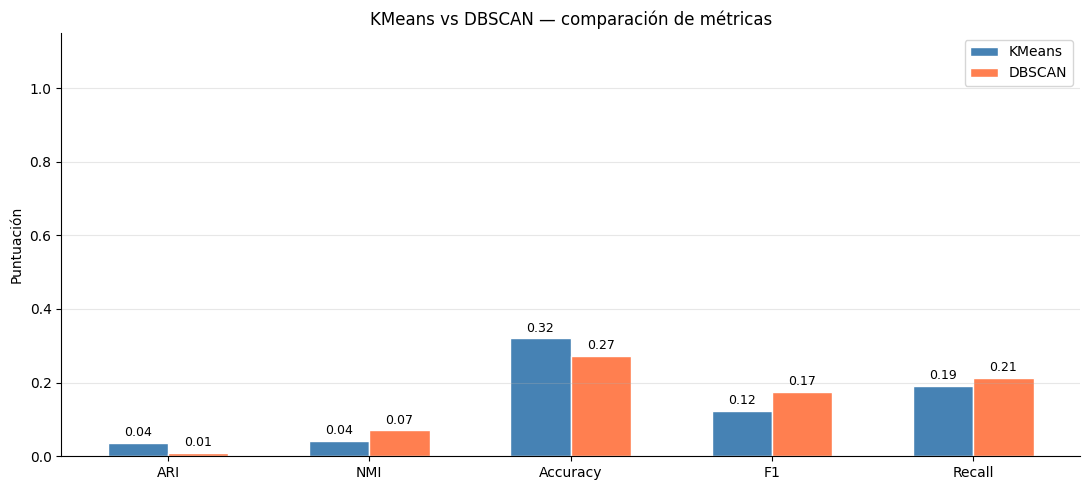


CONCLUSIÓN
  Para este dataset KMeans obtuvo mejor accuracy mapeada.
  KMeans es más adecuado cuando se conoce el número de clases.
  DBSCAN es útil para detectar imágenes atípicas o mal etiquetadas.


In [ ]:
# @title
# ============================================================
# Tabla comparativa de métricas
# ============================================================

print("\n" + "="*65)
print("  COMPARACIÓN KMEANS vs DBSCAN")
print("="*65)
print(f"{'Métrica':<25} {'KMeans':>15} {'DBSCAN':>15}")
print(f"{'-'*65}")

metricas_comp = [
    ("ARI",              ari_km,  ari_db),
    ("NMI",              nmi_km,  nmi_db),
    ("Silueta",          sil_km,  sil_db),
    ("Davies-Bouldin",   db_km,   db_db),
    ("Accuracy mapeada", acc_km,  acc_db),
    ("F1 macro",         f1_km,   f1_db),
    ("Recall macro",     rec_km,  rec_db),
]

for nombre, val_km, val_db in metricas_comp:
    val_km_str = f"{val_km:.3f}" if not np.isnan(val_km) else "N/A"
    val_db_str = f"{val_db:.3f}" if not np.isnan(val_db) else "N/A"
    print(f"{nombre:<25} {val_km_str:>15} {val_db_str:>15}")

print(f"\n{'Clusters encontrados':<25} {k_optimo:>15} {n_clusters_db:>15}")
print(f"{'Clusters esperados':<25} {n_clases:>15} {n_clases:>15}")
print(f"{'Puntos ruido':<25} {'0':>15} {n_ruido_db:>15}")
print("="*65)

# ============================================================
# Gráfica comparativa de métricas
# ============================================================

metricas_graf  = ['ARI', 'NMI', 'Accuracy', 'F1', 'Recall']
valores_km     = [ari_km, nmi_km, acc_km, f1_km, rec_km]
valores_db     = [ari_db, nmi_db, acc_db, f1_db, rec_db]

x     = np.arange(len(metricas_graf))
ancho = 0.3

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - ancho/2, valores_km, ancho,
            label='KMeans', color='steelblue', edgecolor='white')
b2 = ax.bar(x + ancho/2, valores_db, ancho,
            label='DBSCAN', color='coral',     edgecolor='white')

for barras in [b1, b2]:
    for barra in barras:
        alto = barra.get_height()
        if not np.isnan(alto):
            ax.text(barra.get_x() + barra.get_width() / 2,
                    alto + 0.01, f'{alto:.2f}',
                    ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metricas_graf)
ax.set_ylabel('Puntuación')
ax.set_ylim(0, 1.15)
ax.set_title('KMeans vs DBSCAN — comparación de métricas')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# ============================================================
# Tabla de ventajas y limitaciones
# ============================================================




print(f"\n{'CONCLUSIÓN':}")
mejor = 'KMeans' if acc_km >= acc_db else 'DBSCAN'
print(f"  Para este dataset {mejor} obtuvo mejor accuracy mapeada.")
print(f"  KMeans es más adecuado cuando se conoce el número de clases.")
print(f"  DBSCAN es útil para detectar imágenes atípicas o mal etiquetadas.")

#Tecnicas de reducción de dimensiones

In [ ]:
# @title
import numpy as np
from sklearn.preprocessing import StandardScaler

# Extraer features de imágenes reales sin augmentation
X_lista, y_lista = [], []

for img, clase in imagenes_reales:
    img_proc = preprocesar_imagen(img)
    feats    = extraer_caracteristicas(img_proc)
    X_lista.append(feats)
    y_lista.append(clase)

X_raw = np.array(X_lista)
y_raw = encoder.transform(y_lista)

# Escalar — base para ambas técnicas
sc    = StandardScaler()
X_sc  = sc.fit_transform(X_raw)

nombres_clases = encoder.classes_
n_clases       = len(nombres_clases)
colores        = plt.cm.tab20(np.linspace(0, 1, n_clases))

print(f"Shape features: {X_sc.shape}")
print(f"Clases: {list(nombres_clases)}")

Shape features: (4165, 8132)
Clases: [np.str_('Audi'), np.str_('Hyundai Creta'), np.str_('Mahindra Scorpio'), np.str_('Rolls Royce'), np.str_('Swift'), np.str_('Tata Safari'), np.str_('Toyota Innova')]


PCA

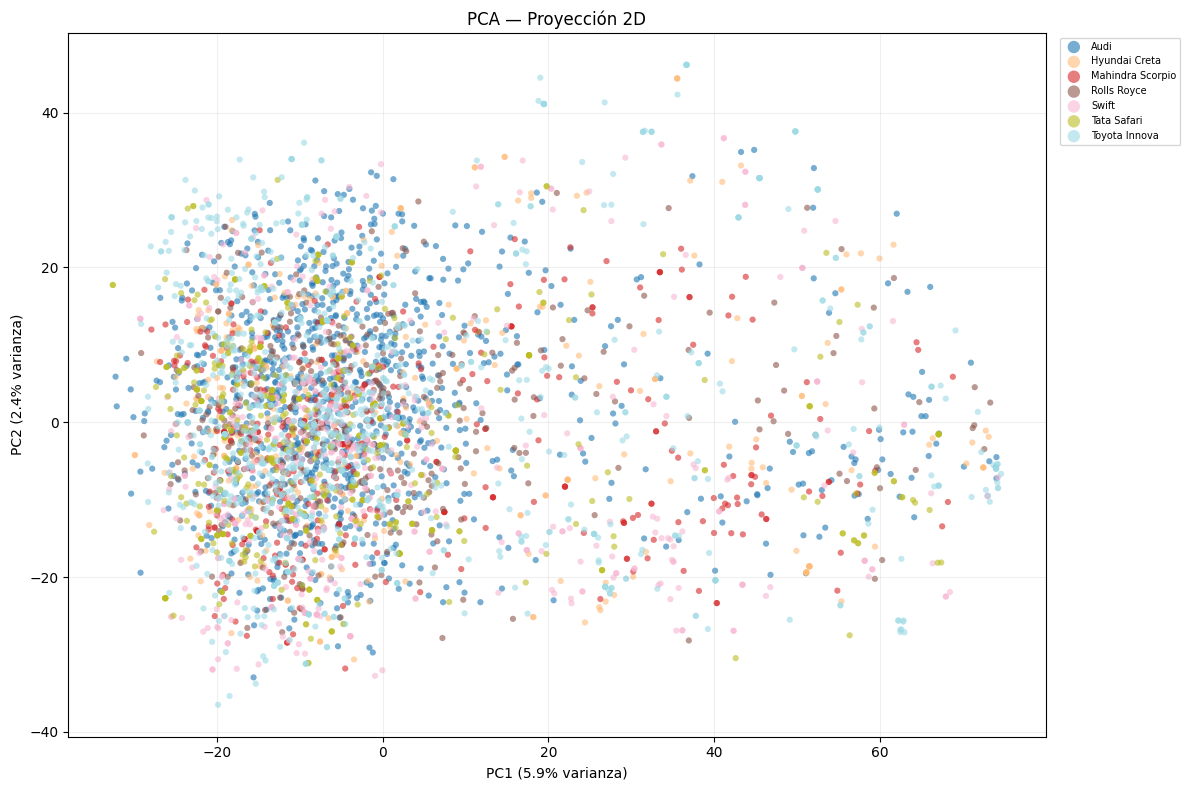

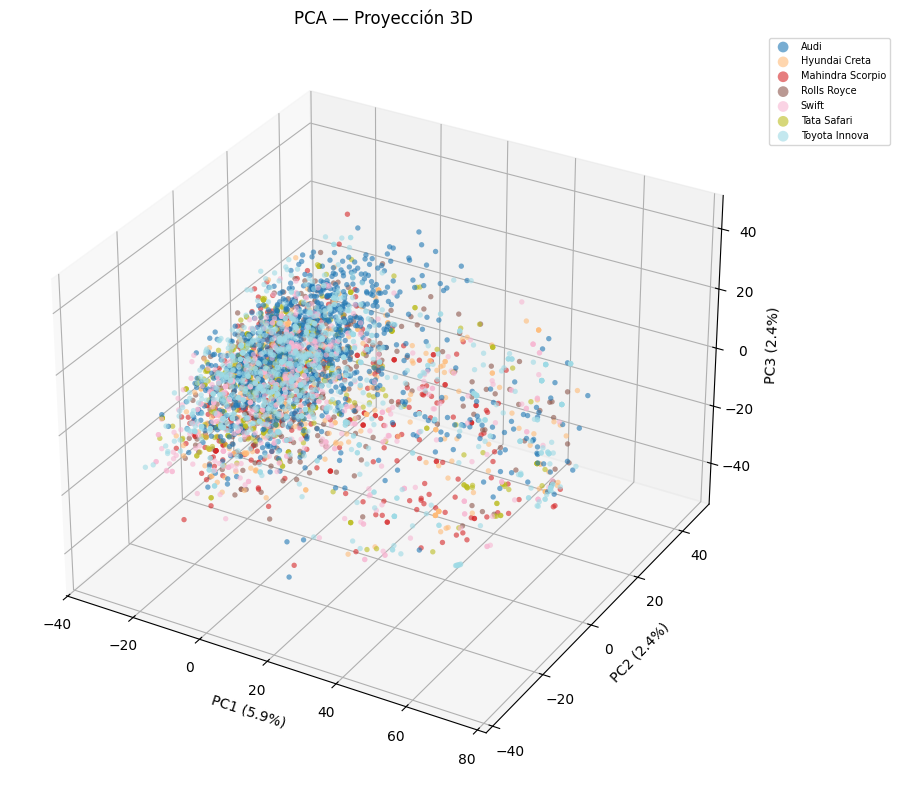

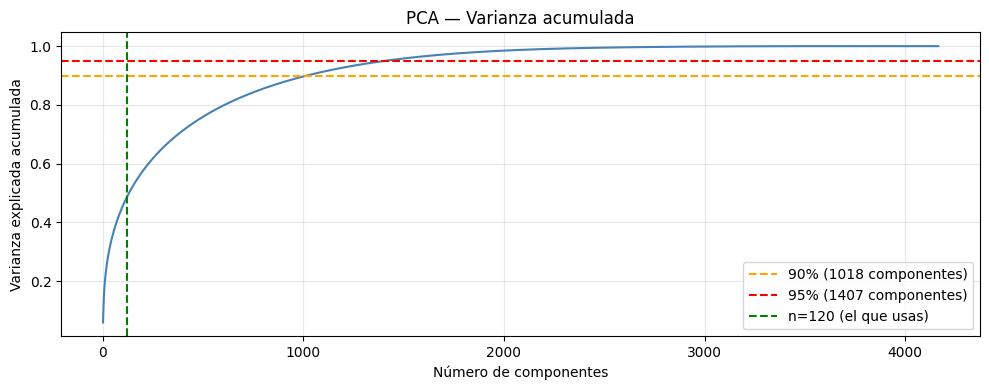

Componentes para 90% de varianza: 1018
Componentes para 95% de varianza: 1407
Varianza explicada por PC1+PC2:   8.3%
Varianza explicada por PC1+PC2+PC3: 10.7%


In [ ]:
# @title
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# PCA 2D
# ============================================================

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_sc)

var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

fig, ax = plt.subplots(figsize=(12, 8))

for i, clase in enumerate(nombres_clases):
    mask = y_raw == i
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
               color=colores[i], label=clase,
               alpha=0.6, s=20, edgecolors='none')

ax.set_xlabel(f"PC1 ({var_pc1:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({var_pc2:.1f}% varianza)")
ax.set_title("PCA — Proyección 2D")
ax.legend(fontsize=7, markerscale=2,
          bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ============================================================
# PCA 3D
# ============================================================

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_sc)

var_pc1 = pca_3d.explained_variance_ratio_[0] * 100
var_pc2 = pca_3d.explained_variance_ratio_[1] * 100
var_pc3 = pca_3d.explained_variance_ratio_[2] * 100

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

for i, clase in enumerate(nombres_clases):
    mask = y_raw == i
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               color=colores[i], label=clase,
               alpha=0.6, s=15, edgecolors='none')

ax.set_xlabel(f"PC1 ({var_pc1:.1f}%)")
ax.set_ylabel(f"PC2 ({var_pc2:.1f}%)")
ax.set_zlabel(f"PC3 ({var_pc3:.1f}%)")
ax.set_title("PCA — Proyección 3D")
ax.legend(fontsize=7, markerscale=2,
          bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================================
# Varianza acumulada — cuántas componentes necesitas
# ============================================================

pca_full = PCA(random_state=42)
pca_full.fit(X_sc)
varianza_acum = np.cumsum(pca_full.explained_variance_ratio_)

comp_90 = np.argmax(varianza_acum >= 0.90) + 1
comp_95 = np.argmax(varianza_acum >= 0.95) + 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(varianza_acum) + 1), varianza_acum,
        color='steelblue', linewidth=1.5)
ax.axhline(0.90, color='orange', linestyle='--', label=f'90% ({comp_90} componentes)')
ax.axhline(0.95, color='red',    linestyle='--', label=f'95% ({comp_95} componentes)')
ax.axvline(120,  color='green',  linestyle='--', label='n=120 (el que usas)')
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Varianza explicada acumulada")
ax.set_title("PCA — Varianza acumulada")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Componentes para 90% de varianza: {comp_90}")
print(f"Componentes para 95% de varianza: {comp_95}")
print(f"Varianza explicada por PC1+PC2:   {var_pc1+var_pc2:.1f}%")
print(f"Varianza explicada por PC1+PC2+PC3: {var_pc1+var_pc2+var_pc3:.1f}%")

t-sne

PCA previo para t-SNE: (4165, 8132) → (4165, 50)
Calculando t-SNE 2D... (puede tardar unos minutos)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


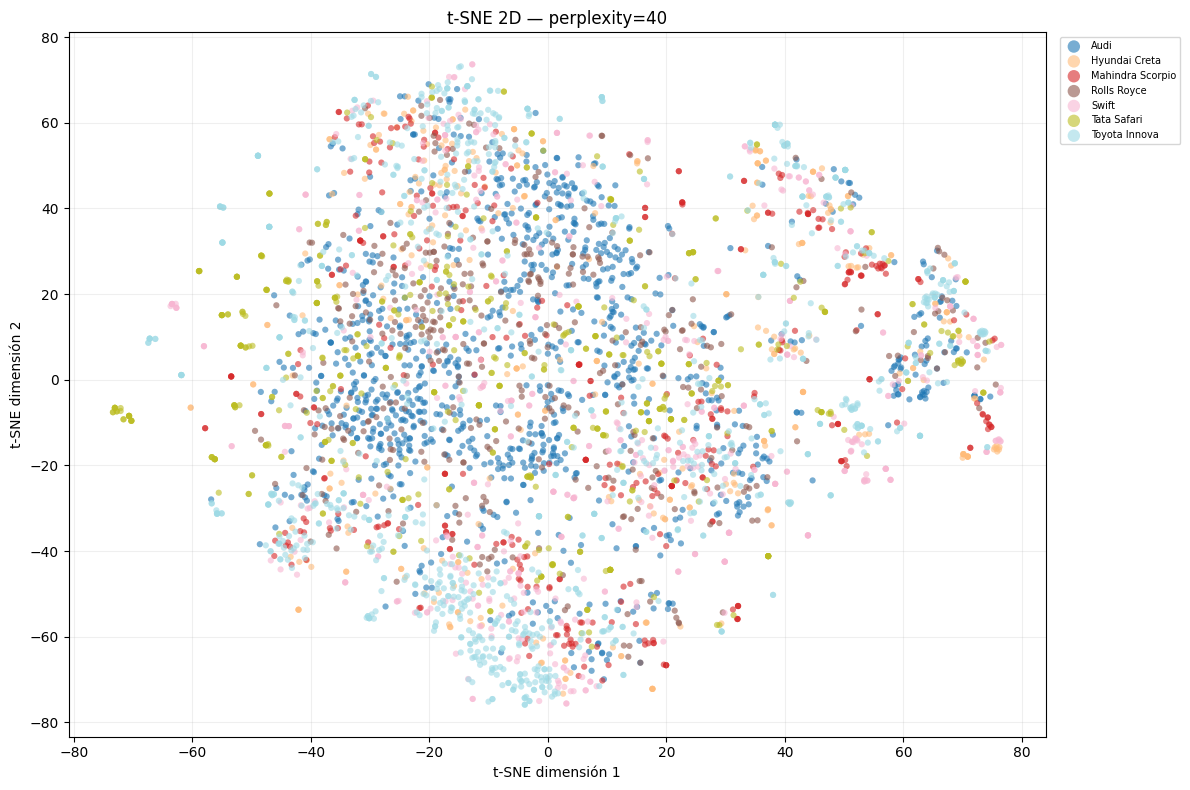

Calculando t-SNE 3D... (puede tardar más)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


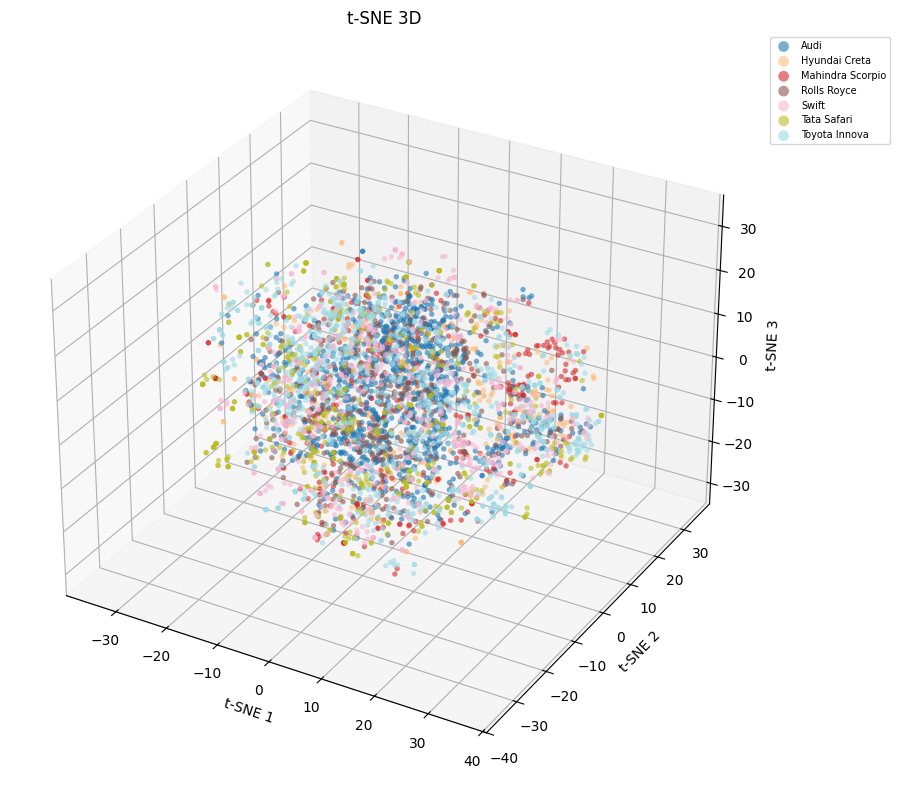

Calculando t-SNE con distintas perplexities...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


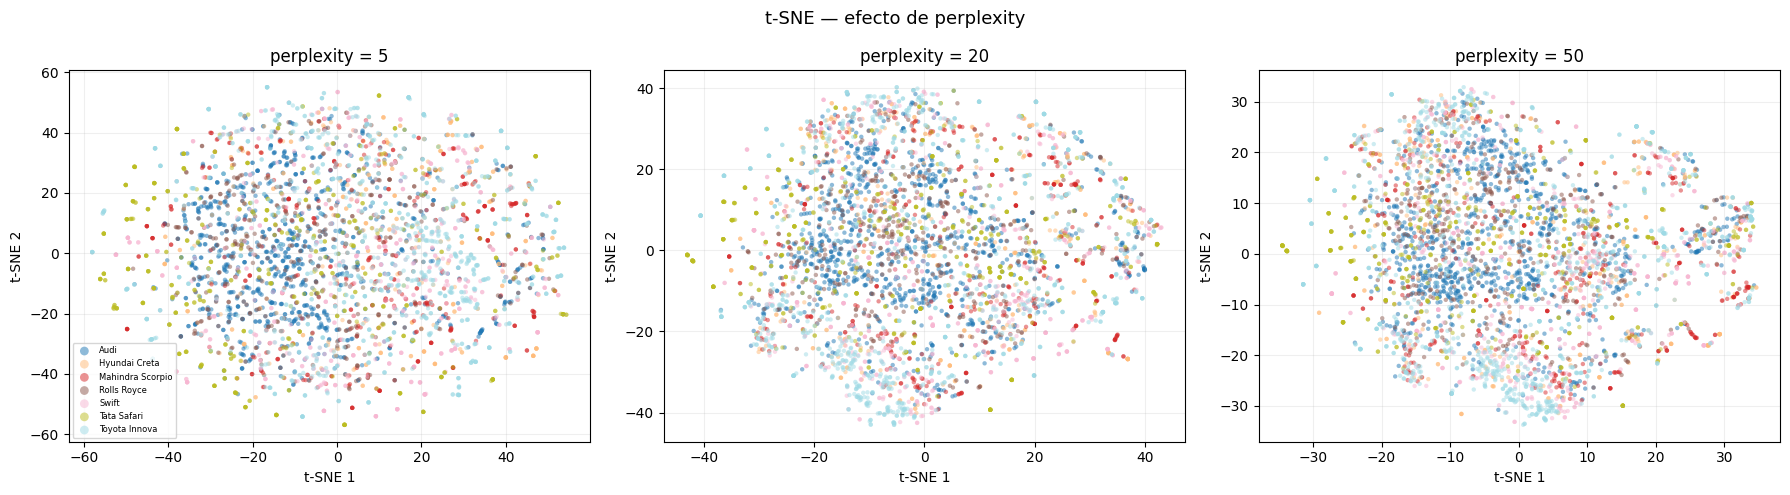

In [ ]:
# @title
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# t-SNE es muy lento sobre 500+ dimensiones
# se recomienda reducir primero con PCA a 50 componentes
# esto es una práctica estándar, no un atajo
pca_pre = PCA(n_components=50, random_state=42)
X_pre   = pca_pre.fit_transform(X_sc)
print(f"PCA previo para t-SNE: {X_sc.shape} → {X_pre.shape}")

# ============================================================
# t-SNE 2D
# ============================================================

print("Calculando t-SNE 2D... (puede tardar unos minutos)")

tsne_2d = TSNE(
    n_components=2,
    perplexity=40,       # balance entre estructura local y global
                         # valores típicos: 5-50
                         # más alto = más contexto global
    learning_rate='auto',
    n_iter=1000,         # iteraciones de optimización
    init='pca',          # inicializar con PCA acelera la convergencia
    random_state=42
)
X_tsne_2d = tsne_2d.fit_transform(X_pre)

fig, ax = plt.subplots(figsize=(12, 8))

for i, clase in enumerate(nombres_clases):
    mask = y_raw == i
    ax.scatter(X_tsne_2d[mask, 0], X_tsne_2d[mask, 1],
               color=colores[i], label=clase,
               alpha=0.6, s=20, edgecolors='none')

ax.set_xlabel("t-SNE dimensión 1")
ax.set_ylabel("t-SNE dimensión 2")
ax.set_title(f"t-SNE 2D — perplexity={tsne_2d.perplexity}")
ax.legend(fontsize=7, markerscale=2,
          bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ============================================================
# t-SNE 3D
# ============================================================

print("Calculando t-SNE 3D... (puede tardar más)")

tsne_3d = TSNE(
    n_components=3,
    perplexity=40,
    learning_rate='auto',
    n_iter=1000,
    init='pca',
    random_state=42
)
X_tsne_3d = tsne_3d.fit_transform(X_pre)

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

for i, clase in enumerate(nombres_clases):
    mask = y_raw == i
    ax.scatter(X_tsne_3d[mask, 0], X_tsne_3d[mask, 1], X_tsne_3d[mask, 2],
               color=colores[i], label=clase,
               alpha=0.6, s=15, edgecolors='none')

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
ax.set_title("t-SNE 3D")
ax.legend(fontsize=7, markerscale=2,
          bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ============================================================
# Efecto de perplexity — cómo cambia la proyección
# ============================================================

print("Calculando t-SNE con distintas perplexities...")

perplexities = [5, 20, 50]
fig, axes    = plt.subplots(1, 3, figsize=(18, 5))

for ax, perp in zip(axes, perplexities):
    tsne_p = TSNE(n_components=2, perplexity=perp,
                  learning_rate='auto', n_iter=500,
                  init='pca', random_state=42)
    X_p = tsne_p.fit_transform(X_pre)

    for i, clase in enumerate(nombres_clases):
        mask = y_raw == i
        ax.scatter(X_p[mask, 0], X_p[mask, 1],
                   color=colores[i], alpha=0.5, s=10,
                   label=clase, edgecolors='none')

    ax.set_title(f"perplexity = {perp}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.grid(alpha=0.2)

axes[0].legend(fontsize=6, markerscale=2)
plt.suptitle("t-SNE — efecto de perplexity", fontsize=13)
plt.tight_layout()
plt.show()

Comparación de las tecnicas

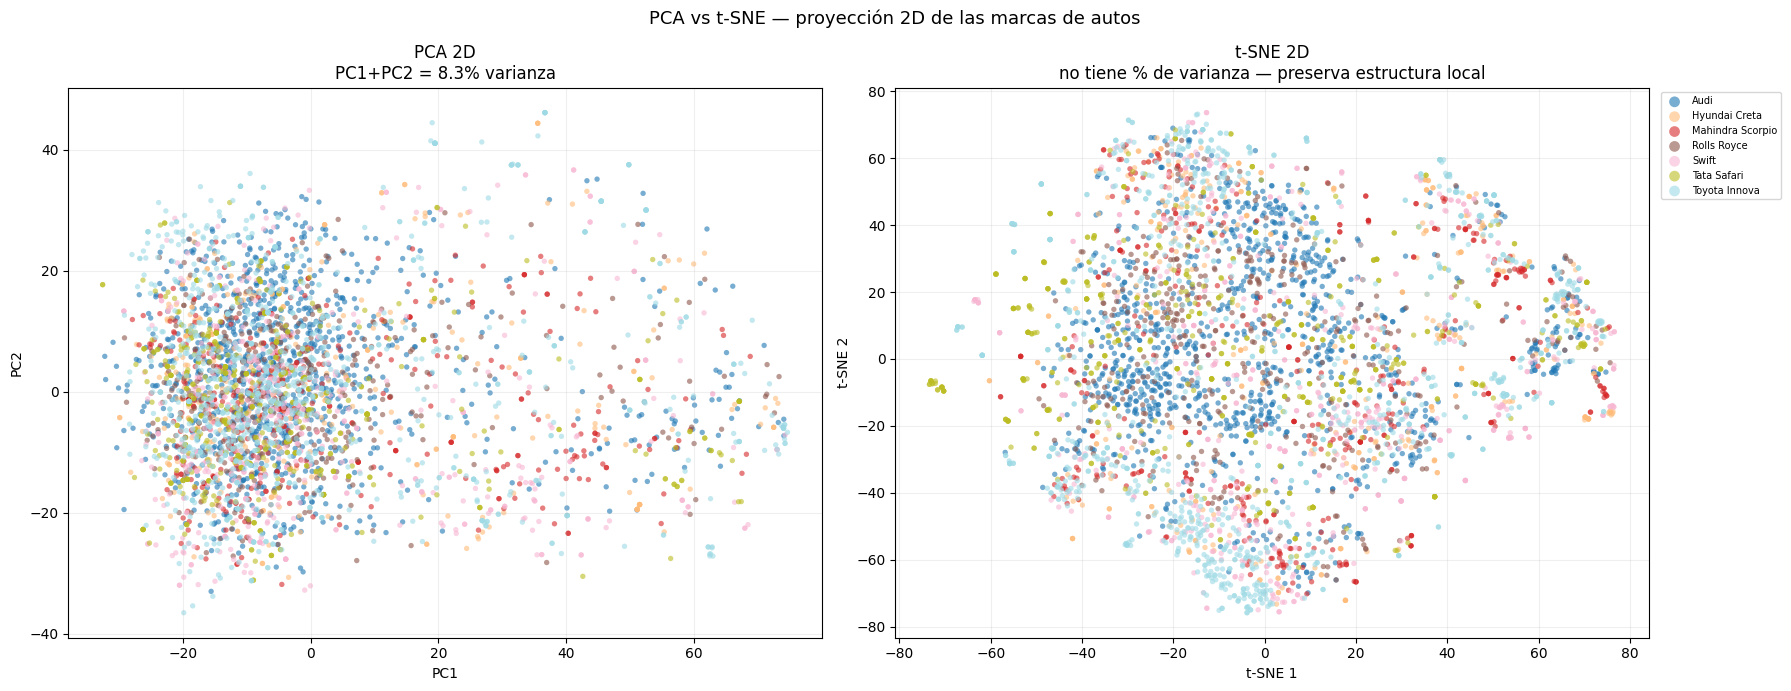


  COMPARACIÓN PCA vs t-SNE
Propiedad                                  PCA           t-SNE
-----------------------------------------------------------------
Tipo de reducción                       lineal       no lineal
Velocidad                           muy rápido           lento
Reproducible                                sí depende de seed
Sirve para predecir             sí (transform)              no
Preserva distancias                   globales         locales
Interpreta varianza                     sí (%)              no
Separa clases similares                   poco           mejor
Útil para clasificar           sí (con NB/SVM) no directamente

Distancia media entre centroides:
  PCA  2D : 4.716
  t-SNE 2D: 10.194

  Mayor distancia = clases más separadas visualmente


In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# Gráfica lado a lado 2D
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, clase in enumerate(nombres_clases):
    mask = y_raw == i
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    color=colores[i], label=clase,
                    alpha=0.6, s=15, edgecolors='none')
    axes[1].scatter(X_tsne_2d[mask, 0], X_tsne_2d[mask, 1],
                    color=colores[i], label=clase,
                    alpha=0.6, s=15, edgecolors='none')

axes[0].set_title(f"PCA 2D\nPC1+PC2 = {(var_pc1+var_pc2):.1f}% varianza")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(alpha=0.2)

axes[1].set_title("t-SNE 2D\nno tiene % de varianza — preserva estructura local")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].grid(alpha=0.2)

axes[1].legend(fontsize=7, markerscale=2,
               bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle("PCA vs t-SNE — proyección 2D de las marcas de autos", fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# Tabla comparativa de propiedades
# ============================================================

print("\n" + "="*65)
print(f"  COMPARACIÓN PCA vs t-SNE")
print("="*65)
print(f"{'Propiedad':<30} {'PCA':>15} {'t-SNE':>15}")
print(f"{'-'*65}")
propiedades = [
    ("Tipo de reducción",       "lineal",          "no lineal"),
    ("Velocidad",               "muy rápido",      "lento"),
    ("Reproducible",            "sí",              "depende de seed"),
    ("Sirve para predecir",     "sí (transform)",  "no"),
    ("Preserva distancias",     "globales",        "locales"),
    ("Interpreta varianza",     "sí (%)",          "no"),
    ("Separa clases similares", "poco",            "mejor"),
    ("Útil para clasificar",    "sí (con NB/SVM)", "no directamente"),
]
for prop, pca_val, tsne_val in propiedades:
    print(f"{prop:<30} {pca_val:>15} {tsne_val:>15}")
print("="*65)

# ============================================================
# Separación entre clases — distancia promedio entre centroides
# cuanto mayor es la distancia, mejor separadas están las clases
# ============================================================

def distancia_media_centroides(X_proj, y):
    """Calcula la distancia euclídea promedio entre todos los centroides."""
    centroides = np.array([X_proj[y == i].mean(axis=0)
                           for i in range(n_clases)])
    distancias = []
    for i in range(n_clases):
        for j in range(i + 1, n_clases):
            distancias.append(np.linalg.norm(centroides[i] - centroides[j]))
    return np.mean(distancias)

dist_pca  = distancia_media_centroides(X_pca_2d,  y_raw)
dist_tsne = distancia_media_centroides(X_tsne_2d, y_raw)

print(f"\nDistancia media entre centroides:")
print(f"  PCA  2D : {dist_pca:.3f}")
print(f"  t-SNE 2D: {dist_tsne:.3f}")
print(f"\n  Mayor distancia = clases más separadas visualmente")